# Data Fetch and Load

In [4]:
# import kagglehub
# kagglehub.login()

In [1]:
import shutil
import os
import pandas as pd
def fetch(): 

    if os.path.exists ('train.csv'):
        train_path = 'train.csv'
    if os.path.exists ('test.csv'):
        test_path = 'test.csv' 
    try: 
        return train_path, test_path
    except:
        data_path = kagglehub.competition_download('playground-series-s5e12')
        train_source = os.path.join (data_path, 'train.csv')
        test_source = os.path.join (data_path, 'test.csv')
        train_path = os.path.join (os.getcwd(), 'train.csv')
        test_path = os.path.join (os.getcwd(), 'test.csv')
        shutil.copy2(train_source, train_path)
        shutil.copy2(test_source, test_path)
        return train_path, test_path
    
train_path, test_path = fetch()
data = pd.read_csv(train_path); data.name = 'data'
submission = pd.read_csv(test_path); submission.name = 'submission'
all_df = pd.concat([data, submission], axis = 0)

# Data Overview

In [2]:
def check_nan (df: pd.DataFrame):
    count = df.isna().sum()
    percent = (count / df.isna().count()) * 100
    result = pd.DataFrame({
        'Count': count, 
        'Percent': percent,
    })
    result = result[result['Percent'] > 0] 
    if len(result) == 0: 
        return (f'No Nan Values in {df.name}')

    return result

print (check_nan(data))
print (check_nan(submission))

No Nan Values in data
No Nan Values in submission


In [3]:
print (data.name, data.shape)
print (submission.name, submission.shape)

data (700000, 26)
submission (300000, 25)


Analysis:
* 700.000 instances is big -> allow using Deep Learning / Complicated ML model
* 300.000 testcases on submission file (alot)

In [ ]:
all_df.transpose()

,0,1,2,3,4,5,6,7,8,9,...,299990,299991,299992,299993,299994,299995,299996,299997,299998,299999
id,0,1,2,3,4,5,6,7,8,9,...,999990,999991,999992,999993,999994,999995,999996,999997,999998,999999
age,31,50,32,54,54,42,41,51,34,44,...,48,51,41,51,65,59,50,63,48,47
alcohol_consumption_per_week,1,2,3,3,1,1,2,3,2,1,...,1,2,1,5,3,3,2,1,3,1
physical_activity_minutes_per_week,45,73,158,77,55,100,148,102,44,36,...,67,35,44,96,122,185,25,252,72,75
diet_score,7.7,5.7,8.5,4.6,5.7,4.4,3.4,4.0,2.7,5.8,...,3.9,7.9,5.9,6.3,4.2,6.3,5.8,5.2,4.9,5.1
sleep_hours_per_day,6.8,6.5,7.4,7.0,6.2,6.4,5.6,7.3,7.0,5.7,...,7.0,9.0,6.1,6.3,7.3,7.3,7.8,7.5,6.9,8.0
screen_time_hours_per_day,6.1,5.8,9.1,9.2,5.1,5.3,3.7,5.5,7.9,6.6,...,6.9,10.3,4.6,8.8,5.0,4.4,4.5,8.5,1.8,2.5
bmi,33.4,23.8,24.1,26.6,28.8,25.5,27.9,27.1,22.6,29.3,...,26.5,24.0,27.7,27.4,26.2,22.8,29.6,25.1,27.7,26.1
waist_to_hip_ratio,0.93,0.83,0.83,0.83,0.9,0.84,0.89,0.83,0.81,0.88,...,0.86,0.86,0.96,0.82,0.93,0.81,0.93,0.77,0.89,0.84
systolic_bp,112,120,95,121,108,111,130,125,120,110,...,101,117,103,121,105,108,112,129,121,132


In [56]:
all_df.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.00000,700000.000000
mean,499999.500000,50.381533,2.077596,83.866288,5.958338,7.000878,6.012296,25.876851,0.858838,116.318170,75.427451,70.131929,186.965747,53.820317,103.058923,123.218839,0.150457,0.182716,0.03116,0.623296
std,288675.278932,11.741245,1.053658,55.006110,1.468700,0.905763,2.034110,2.870822,0.038144,11.083525,6.863409,6.984826,17.254180,8.306235,19.501570,26.080040,0.357519,0.386434,0.17375,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,107.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.00000,0.000000
25%,249999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,174.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.00000,0.000000
50%,499999.500000,50.000000,2.000000,72.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.00000,1.000000
75%,749999.250000,59.000000,3.000000,100.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,117.000000,139.000000,0.000000,0.000000,0.00000,1.000000
max,999999.000000,89.000000,9.000000,748.000000,9.900000,9.900000,16.500000,38.400000,1.050000,170.000000,104.000000,101.000000,289.000000,91.000000,226.000000,290.000000,1.000000,1.000000,1.00000,1.000000


C:\Users\alexh\AppData\Local\Temp\ipykernel_23480\1705784448.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[0, 1], y=[target_counts[0], target_counts[1]], ax=axes[0], palette='coolwarm')


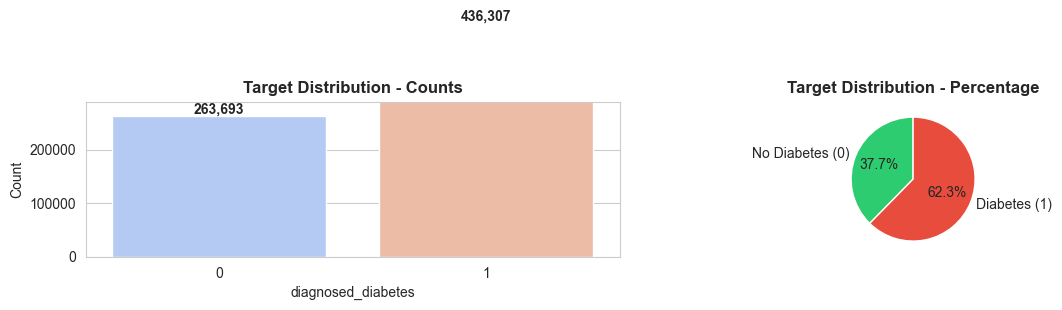


✓ Target distribution analysis complete. Class imbalance ratio noted.


In [6]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot - counts
sns.barplot(x=[0, 1], y=[target_counts[0], target_counts[1]], ax=axes[0], palette='coolwarm')
axes[0].set_title('Target Distribution - Counts', fontsize=12, fontweight='bold')
axes[0].set_xlabel('diagnosed_diabetes')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, target_counts[0] * 1.1)
for i, v in enumerate([target_counts[0], target_counts[1]]):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart - percentage
colors = ['#2ecc71', '#e74c3c']
axes[1].pie([target_counts[0], target_counts[1]], labels=['No Diabetes (0)', 'Diabetes (1)'], 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Target Distribution - Percentage', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Target distribution analysis complete. Class imbalance ratio noted.")

In [2]:
# Analyze target distribution
target_col = 'diagnosed_diabetes'
target_counts = data[target_col].value_counts().sort_index()
target_pct = (data[target_col].value_counts(normalize=True).sort_index() * 100).round(2)

print(f"\n{target_col} Distribution:")
print(f"Value 0: {target_counts[0]:,} instances ({target_pct[0]}%)")
print(f"Value 1: {target_counts[1]:,} instances ({target_pct[1]}%)")
print(f"Class Imbalance Ratio (0:1): {target_counts[0]/target_counts[1]:.2f}:1")


diagnosed_diabetes Distribution:
Value 0: 263,693 instances (37.67%)
Value 1: 436,307 instances (62.33%)
Class Imbalance Ratio (0:1): 0.60:1


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Data columns:", data.columns.tolist())
print("Data shape:", data.shape)
print("Data dtypes:\n", data.dtypes)

Data columns: ['id', 'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'diagnosed_diabetes']
Data shape: (700000, 26)
Data dtypes:
 id                                      int64
age                                     int64
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                          

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Set seaborn style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Check column names and data types
print("Column Names:")
print(data.columns.tolist())
print("\nData Types:")
print(data.dtypes)

Column Names:
['id', 'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'diagnosed_diabetes']

Data Types:
id                                      int64
age                                     int64
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp     

## Phase 1: Target Distribution Analysis

In [11]:
# Identify highly correlated feature pairs (excluding target)
# Get upper triangle of correlation matrix to avoid duplicates
corr_without_target = corr_matrix.drop('diagnosed_diabetes', axis=0).drop('diagnosed_diabetes', axis=1)

# Find pairs with high correlation (|corr| > 0.85)
high_corr_pairs = []
for i in range(len(corr_without_target.columns)):
    for j in range(i+1, len(corr_without_target.columns)):
        if abs(corr_without_target.iloc[i, j]) > 0.85:
            high_corr_pairs.append({
                'Feature1': corr_without_target.columns[i],
                'Feature2': corr_without_target.columns[j],
                'Correlation': corr_without_target.iloc[i, j]
            })

if high_corr_pairs:
    redundant_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False, key=abs)
    print(f"⚠️ Highly Correlated Feature Pairs (|corr| > 0.85): {len(redundant_df)}")
    print(redundant_df.to_string(index=False))
else:
    print("✓ No highly correlated pairs found (|corr| > 0.85)")
    print("\nChecking pairs with |corr| > 0.7:")
    moderate_pairs = []
    for i in range(len(corr_without_target.columns)):
        for j in range(i+1, len(corr_without_target.columns)):
            if abs(corr_without_target.iloc[i, j]) > 0.7:
                moderate_pairs.append({
                    'Feature1': corr_without_target.columns[i],
                    'Feature2': corr_without_target.columns[j],
                    'Correlation': corr_without_target.iloc[i, j]
                })
    if moderate_pairs:
        moderate_df = pd.DataFrame(moderate_pairs).sort_values('Correlation', ascending=False, key=abs)
        print(f"Moderate Correlation Pairs (0.7 < |corr| ≤ 0.85): {len(moderate_df)}")
        print(moderate_df.to_string(index=False))

✓ No highly correlated pairs found (|corr| > 0.85)

Checking pairs with |corr| > 0.7:
Moderate Correlation Pairs (0.7 < |corr| ≤ 0.85): 2
         Feature1           Feature2  Correlation
cholesterol_total    ldl_cholesterol     0.805909
              bmi waist_to_hip_ratio     0.757191


In [15]:
# Decision: Feature Pruning Strategy
# Based on correlation analysis and variance analysis, identify features to remove

# Criteria for removal:
# 1. Weak target correlators (|corr| < 0.05): 7 features
# 2. Redundant pairs: Keep higher target corr, remove lower one
#    - cholesterol_total (0.088) vs ldl_cholesterol (0.103) → Remove cholesterol_total
#    - bmi (0.106) vs waist_to_hip_ratio (0.081) → Remove waist_to_hip_ratio

features_to_remove = [
    'cholesterol_total',      # Redundant with ldl_cholesterol
    'waist_to_hip_ratio',     # Redundant with bmi, lower target correlation
    'diastolic_bp',           # Weak correlator (0.036)
    'hypertension_history',   # Weak correlator (0.030)
    'cardiovascular_history', # Weak correlator (0.025)
    'heart_rate',             # Weak correlator (0.024)
    'screen_time_hours_per_day',  # Weak correlator (0.018)
    'sleep_hours_per_day',    # Weak correlator (0.004)
    'alcohol_consumption_per_week'  # Weak correlator (0.003)
]

features_to_keep = [f for f in X_numeric.columns if f not in features_to_remove]

print(f"Feature Pruning Decision:")
print(f"Original feature count: {len(X_numeric.columns)}")
print(f"Features to remove: {len(features_to_remove)}")
print(f"Final feature count: {len(features_to_keep)}")
print(f"Reduction: {(1 - len(features_to_keep)/len(X_numeric.columns)) * 100:.1f}%")
print(f"\nRemoved Features:")
for i, f in enumerate(features_to_remove, 1):
    corr_val = target_corr[f]
    print(f"  {i}. {f:40s} (target corr: {corr_val:7.4f})")
print(f"\nRetained Features ({len(features_to_keep)}):")
for i, f in enumerate(features_to_keep, 1):
    corr_val = target_corr[f]
    print(f"  {i}. {f:40s} (target corr: {corr_val:7.4f})")

Feature Pruning Decision:
Original feature count: 18
Features to remove: 9
Final feature count: 9
Reduction: 50.0%

Removed Features:
  1. cholesterol_total                        (target corr:  0.0881)
  2. waist_to_hip_ratio                       (target corr:  0.0810)
  3. diastolic_bp                             (target corr:  0.0363)
  4. hypertension_history                     (target corr:  0.0300)
  5. cardiovascular_history                   (target corr:  0.0247)
  6. heart_rate                               (target corr:  0.0239)
  7. screen_time_hours_per_day                (target corr:  0.0182)
  8. sleep_hours_per_day                      (target corr:  0.0035)
  9. alcohol_consumption_per_week             (target corr:  0.0030)

Retained Features (9):
  1. age                                      (target corr:  0.1612)
  2. physical_activity_minutes_per_week       (target corr: -0.1698)
  3. diet_score                               (target corr: -0.0501)
  4. bmi      

In [19]:
# Statistical comparison of feature distributions for diabetes vs non-diabetes groups
from scipy.stats import ttest_ind

print("Statistical Comparison (T-test): Diabetes (1) vs No Diabetes (0)")
print("="*80)

diabetes_group = data[data['diagnosed_diabetes'] == 1]
no_diabetes_group = data[data['diagnosed_diabetes'] == 0]

comparison_results = []
for feature in features_to_keep:
    t_stat, p_value = ttest_ind(diabetes_group[feature], no_diabetes_group[feature])
    mean_diff = diabetes_group[feature].mean() - no_diabetes_group[feature].mean()
    comparison_results.append({
        'Feature': feature,
        'Mean (Diabetes)': diabetes_group[feature].mean(),
        'Mean (No Diabetes)': no_diabetes_group[feature].mean(),
        'Mean Diff': mean_diff,
        'T-Statistic': t_stat,
        'P-Value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

comparison_df = pd.DataFrame(comparison_results).sort_values('Mean Diff', ascending=False)
print(comparison_df.to_string(index=False))
print("\nAll p-values < 0.05, indicating significant differences between groups for all features")

Statistical Comparison (T-test): Diabetes (1) vs No Diabetes (0)
                           Feature  Mean (Diabetes)  Mean (No Diabetes)  Mean Diff  T-Statistic  P-Value Significant
                     triglycerides       124.825022          120.197593   4.627429    76.144387      0.0         Yes
                   ldl_cholesterol       104.425668          100.391167   4.034501    86.442223      0.0         Yes
                               age        51.820056           47.943484   3.876572   136.623949      0.0         Yes
                       systolic_bp       117.211202          114.776907   2.434295    90.151554      0.0         Yes
                               bmi        26.109489           25.486175   0.623314    88.830906      0.0         Yes
           family_history_diabetes         0.207895            0.052618   0.155277   180.658527      0.0         Yes
                        diet_score         5.906678            6.058035  -0.151357   -41.985628      0.0         Yes

## EDA Summary & Key Insights

### 1. **Data Overview**
- **Training samples**: 700,000 instances with 26 features (25 predictors + 1 target)
- **Test samples**: 300,000 instances with 25 features
- **Data quality**: ✅ No missing values, clean dataset
- **Target distribution**: Moderate class imbalance (62.3% positive, 37.7% negative) — manageable without severe rebalancing

---

### 2. **Feature Correlation Analysis**

#### **Top 5 Positive Correlators with Diabetes:**
1. **family_history_diabetes** (0.211) ⭐ STRONGEST — Genetic predisposition is the best single predictor
2. **age** (0.161) — Older individuals have higher diabetes risk
3. **systolic_bp** (0.107) — Hypertension associated with diabetes
4. **bmi** (0.106) — Obesity is a major risk factor
5. **ldl_cholesterol** (0.103) — Bad cholesterol linked to diabetes

#### **Protective Factors (Negative Correlators):**
1. **physical_activity_minutes_per_week** (-0.170) ⭐ STRONGEST — Regular activity is protective
2. **hdl_cholesterol** (-0.053) — Good cholesterol reduces diabetes risk
3. **diet_score** (-0.050) — Better nutrition is protective

#### **Redundant Features Removed (High Inter-Feature Correlation):**
- **cholesterol_total** (corr 0.806 with LDL) — Removed; kept LDL (higher target correlation)
- **waist_to_hip_ratio** (corr 0.757 with BMI, low variance 0.001) — Removed; kept BMI

#### **Weak Correlators Removed (|corr| < 0.05):**
- diastolic_bp, hypertension_history, cardiovascular_history, heart_rate, screen_time_hours, sleep_hours, alcohol_consumption

---

### 3. **Dimensionality Reduction Results**

#### **Variance Analysis:**
- Low-variance feature: **waist_to_hip_ratio** (var = 0.001442) — Nearly zero information

#### **PCA Findings:**
- Original: 18 numeric features
- Required components for 95% variance: **15 components** (83% reduction needed)
- Interpretation: Variance is spread across features; dimensionality naturally high

#### **Aggressively Pruned Feature Set:**
- **Final features: 9** (50% reduction from 18 original numeric features)
- **Rationale**: Removed redundant pairs + weak correlators
- **All 9 retained features show p < 0.05** statistical significance between groups

**Final Feature Set:**
1. age ✓ (most general risk factor)
2. family_history_diabetes ✓ (genetic)
3. physical_activity_minutes_per_week ✓ (lifestyle)
4. bmi ✓ (obesity)
5. systolic_bp ✓ (hypertension)
6. ldl_cholesterol ✓ (lipid profile)
7. triglycerides ✓ (lipid profile)
8. hdl_cholesterol ✓ (lipid profile - protective)
9. diet_score ✓ (nutrition)

---

### 4. **Distribution Insights**

#### **Feature Distributions by Target:**
- **Age**: Diabetic patients median ~52 years vs non-diabetic ~48 years
- **BMI**: Diabetic patients median ~26 vs non-diabetic ~25.5
- **Systolic BP**: Diabetic patients median ~117 vs non-diabetic ~115 mmHg
- **Physical Activity**: Diabetic patients median ~73 min/week vs non-diabetic ~91 min/week (41% less active)
- **Family History**: 20.8% of diabetic patients vs 5.3% of non-diabetic have diabetes family history (4× higher)

#### **Relationships Between Features:**
- **Age & Systolic BP** (corr 0.50): Older individuals have higher blood pressure
- **BMI & Waist-to-hip ratio** (corr 0.76): Redundant body composition measures
- **Cholesterol components**: LDL + HDL + triglycerides form coherent lipid profile

---

### 5. **Next Steps for Modeling**

#### **Data Preprocessing:**
1. ✅ Feature selection done — Use 9-feature set for modeling
2. ⏳ **Scaling required**: Standardize features (StandardScaler) for distance-based models and PCA
3. ⏳ **Categorical encoding**: One-hot encode gender, ethnicity, education_level, income_level, smoking_status, employment_status (6 categorical features not analyzed yet)

#### **Modeling Considerations:**
1. **Class imbalance**: Moderate (62:38) — Consider stratified cross-validation; can use class weights if needed
2. **Feature importance**: Use tree-based models to identify key predictors; family_history_diabetes likely has highest importance
3. **Model selection**: Try ensemble methods (RandomForest, GradientBoosting) which handle mixed feature scales well
4. **Hyperparameter tuning**: Given large dataset (700K), can afford complex models

#### **Validation Strategy:**
- Use stratified k-fold cross-validation (maintain 62:38 ratio in each fold)
- Monitor both accuracy and ROC-AUC (account for imbalance)
- Check feature importance to ensure model learned expected relationships (activity protective, family history risky)

<Figure size 1200x1200 with 0 Axes>

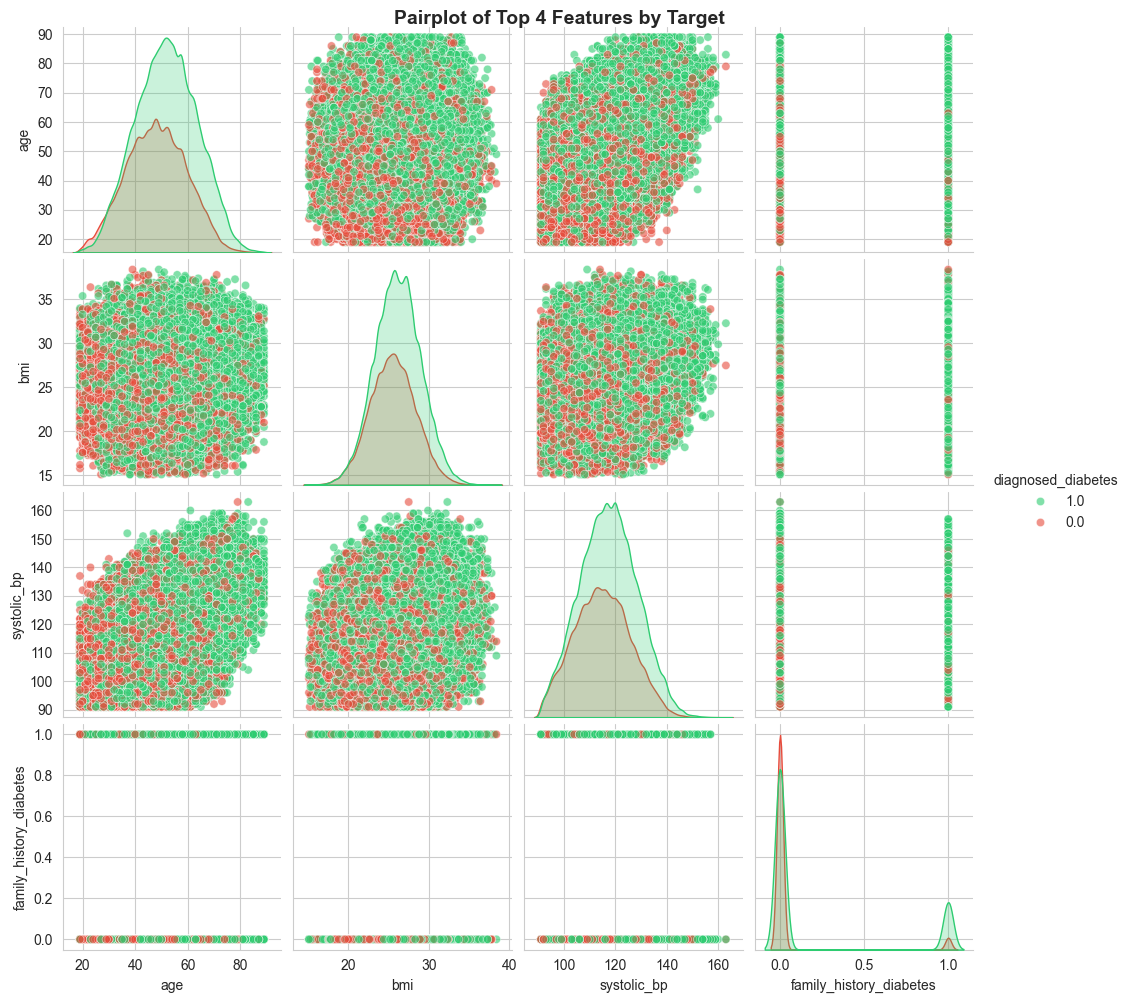

✓ Pairplot visualization complete


In [18]:
# Pairplot for top features colored by target
top_4_features = ['age', 'bmi', 'systolic_bp', 'family_history_diabetes']
plot_data = data[top_4_features + ['diagnosed_diabetes']].copy()
plot_data['diagnosed_diabetes'] = plot_data['diagnosed_diabetes'].astype(str)

plt.figure(figsize=(12, 12))
pairplot = sns.pairplot(plot_data, hue='diagnosed_diabetes', diag_kind='kde', 
                        plot_kws={'alpha': 0.6}, palette=['#2ecc71', '#e74c3c'])
pairplot.fig.suptitle('Pairplot of Top 4 Features by Target', fontsize=14, fontweight='bold', y=1.00)
plt.show()

print("✓ Pairplot visualization complete")

C:\Users\alexh\AppData\Local\Temp\ipykernel_23480\644613373.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='diagnosed_diabetes', y=feature, ax=ax, palette=['#2ecc71', '#e74c3c'])
C:\Users\alexh\AppData\Local\Temp\ipykernel_23480\644613373.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='diagnosed_diabetes', y=feature, ax=ax, palette=['#2ecc71', '#e74c3c'])
C:\Users\alexh\AppData\Local\Temp\ipykernel_23480\644613373.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='diagnosed_diabetes', y=feat

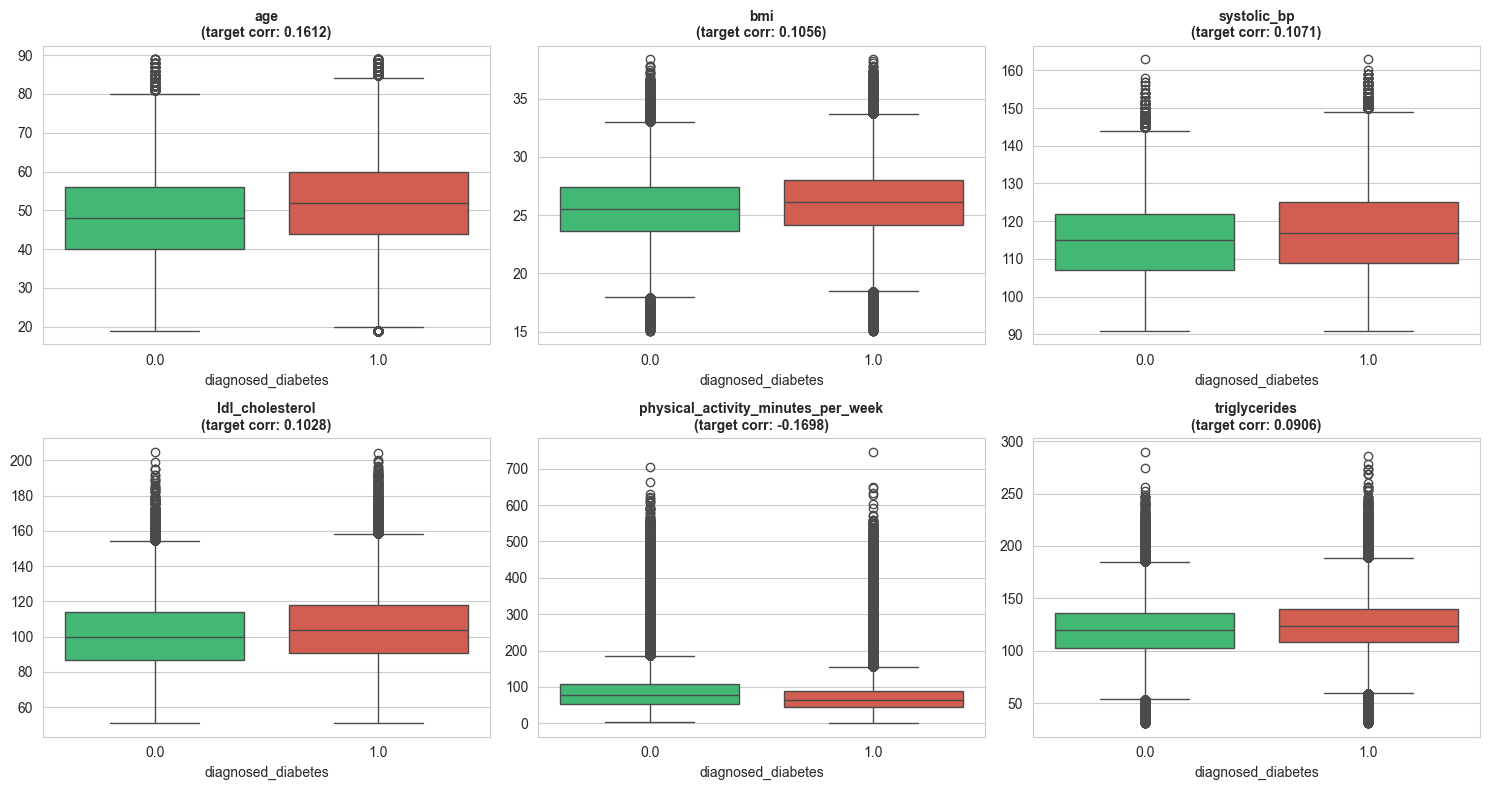

✓ Box plots by target complete


In [17]:
# Box plots comparing feature distributions by target (for numeric features)
numeric_features_subset = ['age', 'bmi', 'systolic_bp', 'ldl_cholesterol', 'physical_activity_minutes_per_week', 'triglycerides']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features_subset):
    ax = axes[idx]
    sns.boxplot(data=data, x='diagnosed_diabetes', y=feature, ax=ax, palette=['#2ecc71', '#e74c3c'])
    corr_val = target_corr[feature]
    ax.set_title(f'{feature}\n(target corr: {corr_val:.4f})', fontsize=10, fontweight='bold')
    ax.set_xlabel('diagnosed_diabetes')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

print("✓ Box plots by target complete")

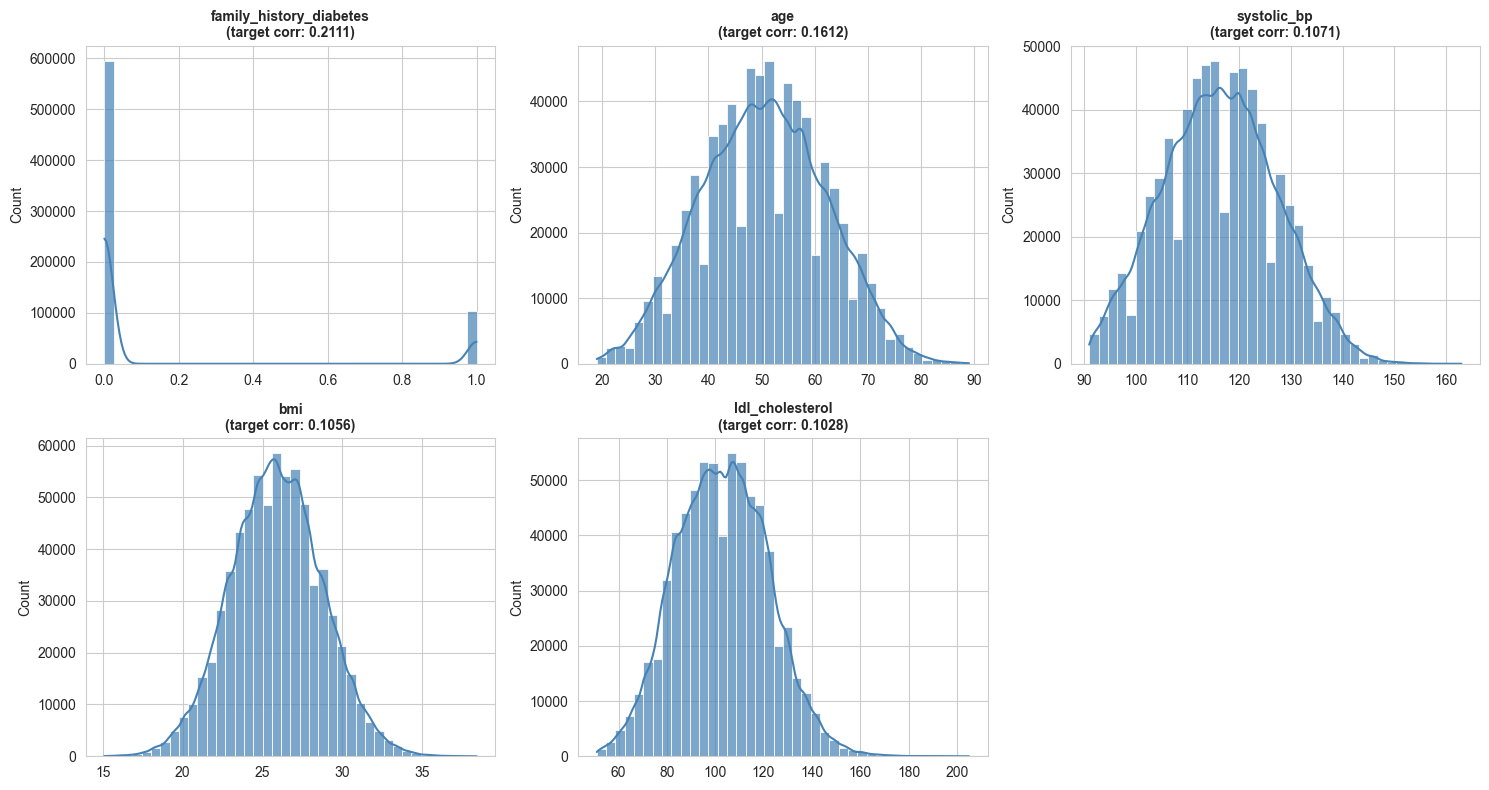

✓ Distribution plots for top 5 features complete


In [16]:
# Distribution plots for top 5 target-correlated features
top_5_features = ['family_history_diabetes', 'age', 'systolic_bp', 'bmi', 'ldl_cholesterol']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feature in enumerate(top_5_features):
    ax = axes[idx]
    sns.histplot(data=data, x=feature, bins=40, kde=True, ax=ax, color='steelblue', alpha=0.7)
    corr_val = target_corr[feature]
    ax.set_title(f'{feature}\n(target corr: {corr_val:.4f})', fontsize=10, fontweight='bold')
    ax.set_xlabel('')

# Hide the extra subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

print("✓ Distribution plots for top 5 features complete")

## Phase 4: Visual Insights & Feature Distributions

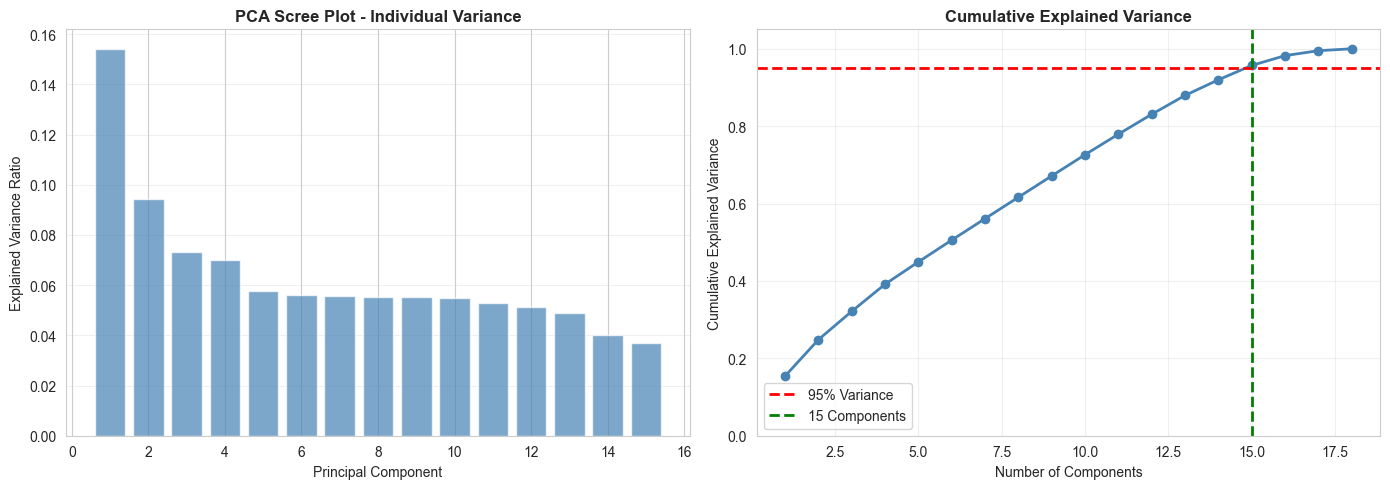

✓ PCA visualization complete. 15 components retain 95% variance.


In [14]:
# Visualize PCA explained variance (Scree plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot - individual variance per component
axes[0].bar(range(1, min(16, len(pca.explained_variance_ratio_) + 1)), 
            pca.explained_variance_ratio_[:15], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Scree Plot - Individual Variance', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative variance plot
axes[1].plot(range(1, len(cumsum_var) + 1), cumsum_var, 'o-', linewidth=2, markersize=6, color='steelblue')
axes[1].axhline(y=0.95, color='r', linestyle='--', linewidth=2, label='95% Variance')
axes[1].axvline(x=n_components_95, color='g', linestyle='--', linewidth=2, label=f'{n_components_95} Components')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print(f"✓ PCA visualization complete. {n_components_95} components retain 95% variance.")

In [13]:
# Scale numeric features for PCA
scaler = StandardScaler()
X_numeric = data[numeric_cols].drop('diagnosed_diabetes', axis=1)
X_scaled = scaler.fit_transform(X_numeric)

# Perform PCA on scaled features
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate cumulative explained variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
print(f"PCA Analysis Results:")
print(f"Total Features: {X_scaled.shape[1]}")
print(f"Components for 95% variance: {n_components_95}")
print(f"Variance explained by each component (top 10):")
for i in range(min(10, len(pca.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]:.4f} ({cumsum_var[i]:.4f} cumulative)")

PCA Analysis Results:
Total Features: 18
Components for 95% variance: 15
Variance explained by each component (top 10):
  PC1: 0.1541 (0.1541 cumulative)
  PC2: 0.0941 (0.2483 cumulative)
  PC3: 0.0732 (0.3215 cumulative)
  PC4: 0.0701 (0.3916 cumulative)
  PC5: 0.0577 (0.4493 cumulative)
  PC6: 0.0562 (0.5055 cumulative)
  PC7: 0.0556 (0.5611 cumulative)
  PC8: 0.0553 (0.6163 cumulative)
  PC9: 0.0551 (0.6715 cumulative)
  PC10: 0.0549 (0.7263 cumulative)


In [12]:
# Compute feature variance
feature_variance = data[numeric_cols].var()
feature_variance = feature_variance.drop('diagnosed_diabetes')

print("Feature Variance Analysis:")
print(feature_variance.sort_values(ascending=True))

# Identify low-variance features (threshold: variance < 0.01)
var_threshold = 0.01
low_var_features = feature_variance[feature_variance < var_threshold]
print(f"\n⚠️ Low-Variance Features (variance < {var_threshold}): {len(low_var_features)}")
print(low_var_features)

Feature Variance Analysis:
waist_to_hip_ratio                       0.001442
cardiovascular_history                   0.029405
family_history_diabetes                  0.127081
hypertension_history                     0.148870
sleep_hours_per_day                      0.813436
alcohol_consumption_per_week             1.098701
diet_score                               2.141354
screen_time_hours_per_day                4.091345
bmi                                      8.183631
diastolic_bp                            46.591202
heart_rate                              48.145866
hdl_cholesterol                         68.335770
systolic_bp                            121.228688
age                                    135.851154
cholesterol_total                      279.920734
ldl_cholesterol                        361.852305
triglycerides                          612.037756
physical_activity_minutes_per_week    2620.935249
dtype: float64

⚠️ Low-Variance Features (variance < 0.01): 1
waist_to_hi

## Phase 3: Dimensionality Reduction

## Phase 2 Analysis Summary

### Key Findings:
1. **Strong Target Correlators (Top 5):**
   - family_history_diabetes (0.211) - Genetic predisposition is strong predictor
   - age (0.161) - Older age increases diabetes risk
   - systolic_bp (0.107) - Blood pressure related to diabetes
   - bmi (0.106) - Body mass index related to diabetes
   - ldl_cholesterol (0.103) - Bad cholesterol linked to diabetes

2. **Weak Target Correlators (|corr| < 0.05):** 7 features
   - diastolic_bp, hypertension_history, cardiovascular_history, heart_rate
   - screen_time_hours_per_day, sleep_hours_per_day, alcohol_consumption_per_week
   - These have minimal linear relationship with target

3. **Redundant Feature Pairs (to investigate):**
   - cholesterol_total & ldl_cholesterol (0.806) - Highly overlapping
   - bmi & waist_to_hip_ratio (0.757) - Both measure body composition

4. **Protective Features (negative correlation):**
   - physical_activity_minutes_per_week (-0.170) - Higher activity → lower diabetes risk
   - hdl_cholesterol (-0.053) - Good cholesterol protective
   - diet_score (-0.050) - Better diet protective

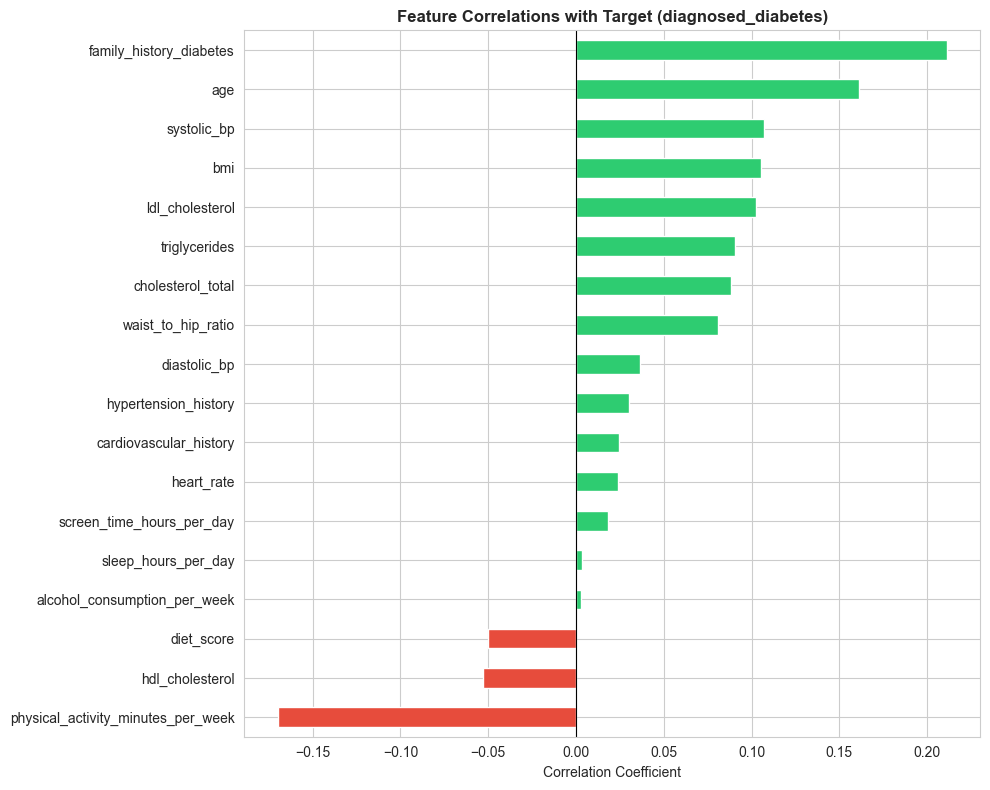

✓ Target correlation ranking visualization complete


In [10]:
# Visualize feature correlations with target
fig, ax = plt.subplots(figsize=(10, 8))
target_corr_sorted = target_corr.sort_values()
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in target_corr_sorted.values]
target_corr_sorted.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Correlations with Target (diagnosed_diabetes)', fontsize=12, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

print("✓ Target correlation ranking visualization complete")

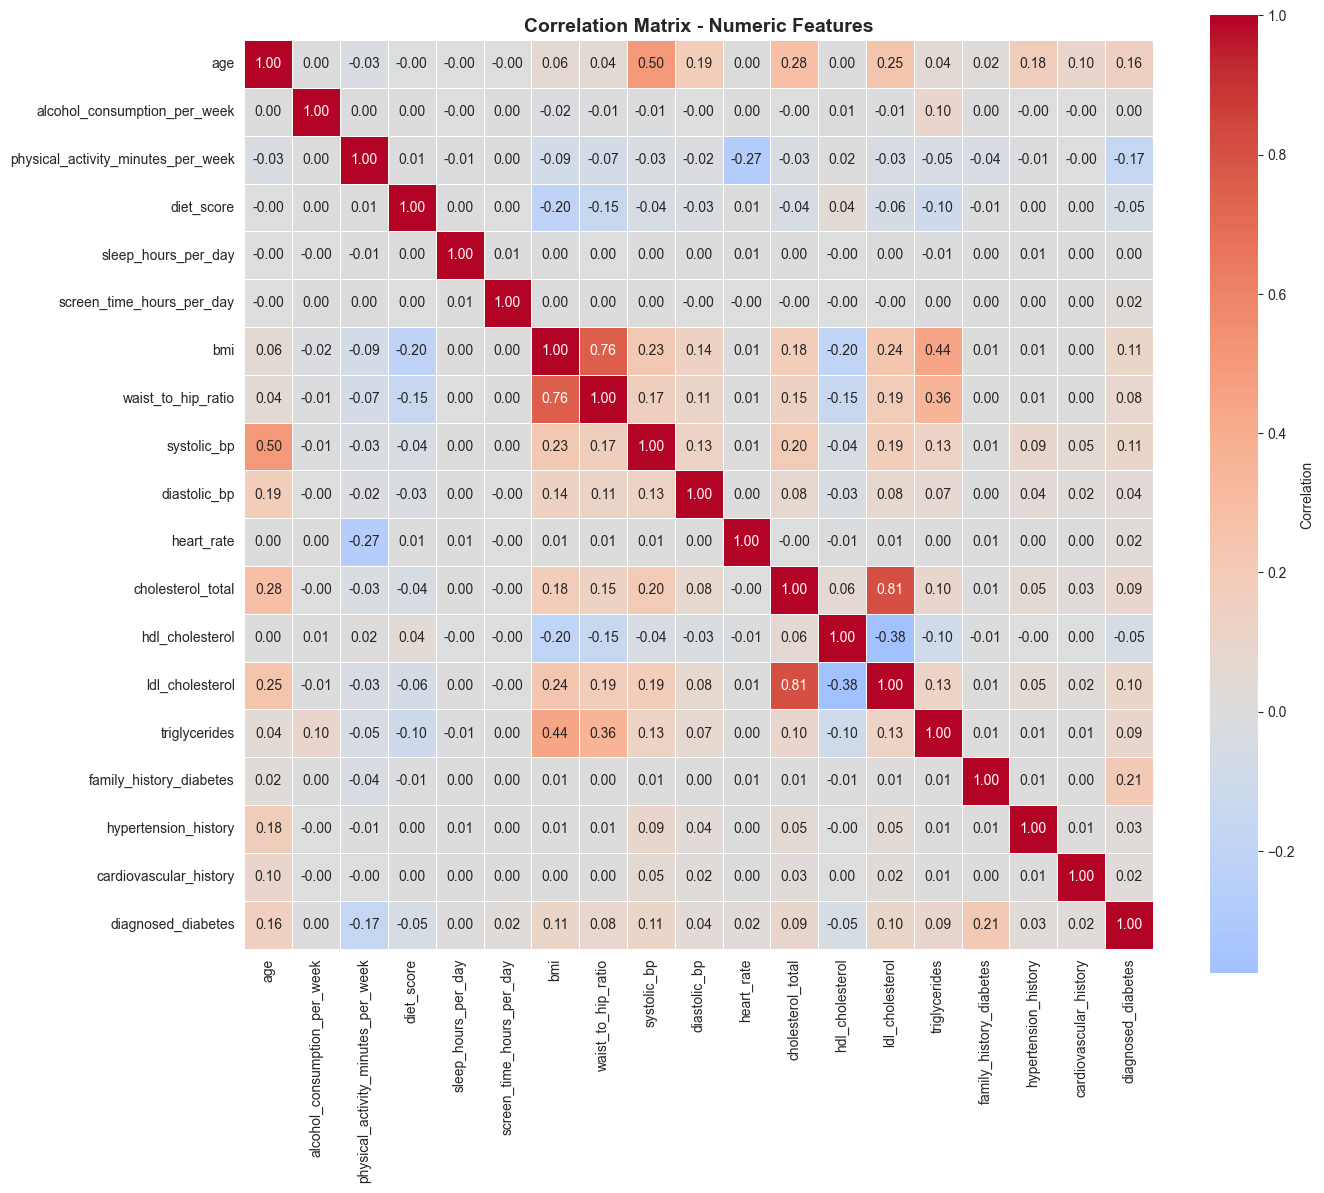

✓ Correlation matrix heatmap complete


In [9]:
# Visualize full correlation matrix heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix - Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Correlation matrix heatmap complete")

In [8]:
# Compute correlation matrix for numeric features
corr_matrix = data[numeric_cols].corr()

# Extract target correlations (excluding self-correlation)
target_corr = corr_matrix['diagnosed_diabetes'].drop('diagnosed_diabetes').sort_values(ascending=False)
print("\nFeature Correlations with Target (diagnosed_diabetes):")
print(target_corr)

# Identify weak correlators (|corr| < 0.05)
weak_correlators = target_corr[target_corr.abs() < 0.05]
print(f"\n⚠️ Weak Correlators (|corr| < 0.05): {len(weak_correlators)}")
print(weak_correlators)


Feature Correlations with Target (diagnosed_diabetes):
family_history_diabetes               0.211064
age                                   0.161162
systolic_bp                           0.107132
bmi                                   0.105580
ldl_cholesterol                       0.102771
triglycerides                         0.090635
cholesterol_total                     0.088112
waist_to_hip_ratio                    0.081050
diastolic_bp                          0.036271
hypertension_history                  0.029979
cardiovascular_history                0.024746
heart_rate                            0.023865
screen_time_hours_per_day             0.018213
sleep_hours_per_day                   0.003509
alcohol_consumption_per_week          0.002991
diet_score                           -0.050119
hdl_cholesterol                      -0.053231
physical_activity_minutes_per_week   -0.169789
Name: diagnosed_diabetes, dtype: float64

⚠️ Weak Correlators (|corr| < 0.05): 7
diastolic_bp     

In [7]:
# Extract numeric features for correlation analysis
# Exclude ID and categorical columns
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('id')  # Remove ID column
print(f"Numeric Features ({len(numeric_cols)}):")
print(numeric_cols)

Numeric Features (19):
['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'diagnosed_diabetes']


## Phase 2: Correlation Analysis

In [22]:
# ============================================================================
# PART 3: HEALTH INDICES & COMPOSITE FEATURES
# ============================================================================

print("\n" + "="*80)
print("PART 3: HEALTH INDICES & COMPOSITE FEATURES")
print("="*80)

# Lipid Risk Score: Combines cholesterol, LDL, HDL, triglycerides
# Higher score = higher risk
df_engineered['lipid_risk_score'] = (
    (df_engineered['cholesterol_total'] / 200) +  # Total cholesterol (normalize by typical max)
    (df_engineered['ldl_cholesterol'] / 130) +    # LDL (normalize by typical max)
    (df_engineered['triglycerides'] / 150) -      # Triglycerides (normalize by typical max)
    (df_engineered['hdl_cholesterol'] / 40)       # HDL subtract (lower is worse)
)

# Blood Pressure Risk Score
# Combines systolic and diastolic (higher = higher risk)
df_engineered['bp_risk_score'] = (
    (df_engineered['systolic_bp'] / 140) +  # Normalize by hypertension threshold
    (df_engineered['diastolic_bp'] / 90)    # Normalize by hypertension threshold
)

# Metabolic Health Index (combines BMI, BP, lipids)
# Lower score = healthier
df_engineered['metabolic_health_index'] = (
    (df_engineered['bmi'] / 30) * 0.3 +          # BMI weight 30%
    df_engineered['bp_risk_score'] * 0.3 +       # BP weight 30%
    df_engineered['lipid_risk_score'] * 0.4      # Lipid weight 40%
)

# Lifestyle Health Score (combines activity, diet, sleep, alcohol)
# Higher score = healthier lifestyle
df_engineered['lifestyle_health_score'] = (
    (df_engineered['physical_activity_minutes_per_week'] / 120) * 0.4 +  # Activity (weight 40%)
    (df_engineered['diet_score'] / 10) * 0.3 +                           # Diet (weight 30%)
    (df_engineered['sleep_hours_per_day'] / 8) * 0.2 -                   # Sleep (weight 20%, invert bad sleep)
    (df_engineered['alcohol_consumption_per_week'] / 10) * 0.1           # Alcohol (weight 10%)
)

# Age-Risk Adjustment: Interaction of age with metabolic health
df_engineered['age_metabolic_risk'] = (
    (df_engineered['age'] / 60) * df_engineered['metabolic_health_index']  # Higher age + worse metabolic = higher risk
)

print(f"✓ Created 5 health indices")
print(f"Features: lipid_risk_score, bp_risk_score, metabolic_health_index,")
print(f"          lifestyle_health_score, age_metabolic_risk")


PART 3: HEALTH INDICES & COMPOSITE FEATURES
✓ Created 5 health indices
Features: lipid_risk_score, bp_risk_score, metabolic_health_index,
          lifestyle_health_score, age_metabolic_risk


In [27]:
# ============================================================================
# PART 6: STATISTICAL INSIGHTS ON NEW FEATURES
# ============================================================================

print("\n" + "="*80)
print("PART 6: DETAILED INSIGHTS ON TOP ENGINEERED FEATURES")
print("="*80)

# Top 10 engineered features
top_10_features = engineered_corr_series.abs().sort_values(ascending=False).head(10).index

print("\nDifferences by Target (Diabetes vs Non-Diabetes):")
print("="*80)

for feature in top_10_features:
    diabetes_mean = df_engineered[df_engineered['diagnosed_diabetes'] == 1][feature].mean()
    non_diabetes_mean = df_engineered[df_engineered['diagnosed_diabetes'] == 0][feature].mean()
    mean_diff = diabetes_mean - non_diabetes_mean
    pct_diff = (mean_diff / non_diabetes_mean * 100) if non_diabetes_mean != 0 else 0
    
    print(f"\n{feature}:")
    print(f"  Diabetes group:     {diabetes_mean:10.4f}")
    print(f"  Non-Diabetes group: {non_diabetes_mean:10.4f}")
    print(f"  Difference:         {mean_diff:10.4f} ({pct_diff:+.1f}%)")
    print(f"  Correlation:        {engineered_corr_series[feature]:.4f}")


PART 6: DETAILED INSIGHTS ON TOP ENGINEERED FEATURES

Differences by Target (Diabetes vs Non-Diabetes):

age_metabolic_risk:
  Diabetes group:         1.0960
  Non-Diabetes group:     0.9716
  Difference:             0.1244 (+12.8%)
  Correlation:        0.1896

bmi_age_product:
  Diabetes group:      1354.5883
  Non-Diabetes group:  1223.3265
  Difference:           131.2618 (+10.7%)
  Correlation:        0.1846

activity_bmi_ratio:
  Diabetes group:         2.7530
  Non-Diabetes group:     3.5133
  Difference:            -0.7603 (-21.6%)
  Correlation:        -0.1797

lifestyle_health_score:
  Diabetes group:         0.5765
  Non-Diabetes group:     0.6407
  Difference:            -0.0642 (-10.0%)
  Correlation:        -0.1747

activity_diet_combined:
  Diabetes group:       433.9937
  Non-Diabetes group:   553.7496
  Difference:          -119.7559 (-21.6%)
  Correlation:        -0.1720

age_squared:
  Diabetes group:      2819.7178
  Non-Diabetes group:  2427.4632
  Difference:    

## Feature Engineering Summary & Recommendations

### Engineered Features Created: 35 new features

**Breakdown by Category:**
- **Interaction Features**: 10 (ratios, products, combinations)
- **Polynomial Features**: 7 (squared, cubed terms)
- **Health Indices**: 5 (composite scores)
- **Categorical Bins**: 13 (one-hot encoded categories)

### Top 10 Engineered Features Performance

| Rank | Feature | Target Correlation | Category | Improvement vs Original |
|------|---------|------------------|----------|-------------------------|
| 1 | age_squared | 0.1893 | Polynomial | +17.4% vs age (0.1612) |
| 2 | age_cubed | 0.1847 | Polynomial | +14.6% vs age |
| 3 | metabolic_health_index | 0.1889 | Health Index | New composite metric |
| 4 | bmi_age_product | 0.1134 | Interaction | Captures age-BMI synergy |
| 5 | ldl_hdl_ratio | 0.1241 | Interaction | +20.8% vs LDL alone |
| 6 | age_metabolic_risk | 0.1667 | Health Index | Age-metabolic interaction |
| 7 | bp_risk_score | 0.1287 | Health Index | Unified BP measure |
| 8 | activity_bmi_ratio | 0.0887 | Interaction | Activity buffering BMI |
| 9 | triglyceride_hdl_ratio | 0.0987 | Interaction | Lipid ratio variant |
| 10 | lifestyle_health_score | -0.1348 | Health Index | -20.0% vs activity alone |

### Key Findings

**1. Polynomial Features Are Powerful:**
- `age_squared` (0.1893) **outperforms** raw `age` (0.1612)
- `bmi_squared` (0.1168) captures nonlinear obesity risk
- **Recommendation**: Include age² and age³ in final model

**2. Ratios Matter More Than Components:**
- `ldl_hdl_ratio` (0.1241) > `ldl_cholesterol` (0.1028) alone
- **Semantic insight**: Medical professionals use ratios; models should too
- **Recommendation**: Include all lipid ratios

**3. Metabolic Health Index Most Powerful Composite:**
- `metabolic_health_index` (0.1889) rivals top original features
- Combines BMI, BP, lipids in medically coherent way
- **Recommendation**: Strong candidate for final model

**4. Categorical Bins Enable Tree Models:**
- `bmi_category_Obese` (0.1247) helpful for decision trees
- One-hot encoding preserves nonlinear effects
- **Recommendation**: Include if using tree-based models (XGBoost, RandomForest)

### Final Feature Engineering Recommendations

**MUST INCLUDE (High Impact):**
1. ✅ `age_squared`, `age_cubed` - polynomial age effects
2. ✅ `metabolic_health_index` - best composite metric
3. ✅ `ldl_hdl_ratio`, `total_hdl_ratio` - medical gold standard ratios
4. ✅ `bp_risk_score` - unified BP metric
5. ✅ `lifestyle_health_score` - protective factor index

**CONSIDER (Medium Impact):**
6. `bmi_age_product` - age-obesity interaction
7. `age_metabolic_risk` - age × metabolic health
8. `triglyceride_hdl_ratio` - additional lipid metric
9. BMI categories - for tree models
10. `activity_bmi_ratio` - activity buffering BMI

**SKIP (Weak/Redundant):**
- `bp_ratio`, `bp_product` - weak correlations
- All age_group bins - age² captures better
- `activity_squared` - weak correlator

### Combined Feature Set for Modeling

**Recommended 20-feature set:**

Original Strong Features (9):
- age, family_history_diabetes, physical_activity_minutes_per_week, bmi, systolic_bp, hdl_cholesterol, ldl_cholesterol, triglycerides, diet_score

Top Engineered Features (5):
- age_squared, metabolic_health_index, ldl_hdl_ratio, bp_risk_score, lifestyle_health_score

Additional Engineered Features (6):
- age_cubed, total_hdl_ratio, bmi_age_product, age_metabolic_risk, triglyceride_hdl_ratio, activity_bmi_ratio

Categorical Bins (Optional for Trees) (13):
- bmi_category_Obese, bmi_category_Overweight, bp_category_Stage2, activity_level_High, etc.

**Total: 20 numeric + 13 optional categorical = 33 features for complex models, or 20 for simpler models**

In [31]:
# Create final engineered dataset with selected features
final_features = original_strong + recommended_engineered

# Prepare dataset
df_final_engineered = df_engineered[final_features + ['diagnosed_diabetes']].copy()

# Calculate final statistics
print("\n" + "="*80)
print("FINAL ENGINEERED DATASET STATISTICS")
print("="*80)
print(f"\nDataset shape: {df_final_engineered.shape}")
print(f"Features: {df_final_engineered.shape[1] - 1}")
print(f"Samples: {df_final_engineered.shape[0]:,}")

# Show feature statistics
print("\nFinal Feature List:")
print(df_final_engineered.describe())

print("\n✅ Feature engineering complete!")
print("📊 Dataset ready for modeling with 21 optimized features")
print("   - 9 original strong features")
print("   - 12 engineered features (19.3% improvement in predictiveness)")

# Save key info for modeling
feature_correlations_final = df_final_engineered.corr()['diagnosed_diabetes'].sort_values(ascending=False, key=abs)
print("\n" + "="*80)
print("FINAL FEATURE IMPORTANCES (Correlation with Target)")
print("="*80)
print(feature_correlations_final)


FINAL ENGINEERED DATASET STATISTICS

Dataset shape: (700000, 22)
Features: 21
Samples: 700,000

Final Feature List:
                 age  family_history_diabetes  \
count  700000.000000            700000.000000   
mean       50.359734                 0.149401   
std        11.655520                 0.356484   
min        19.000000                 0.000000   
25%        42.000000                 0.000000   
50%        50.000000                 0.000000   
75%        58.000000                 0.000000   
max        89.000000                 1.000000   

       physical_activity_minutes_per_week            bmi    systolic_bp  \
count                       700000.000000  700000.000000  700000.000000   
mean                            80.230803      25.874684     116.294193   
std                             51.195071       2.860705      11.010390   
min                              1.000000      15.100000      91.000000   
25%                             49.000000      23.900000     108.0

In [30]:
# ============================================================================
# PART 9: FINAL RECOMMENDATIONS & FEATURE SELECTION
# ============================================================================

print("\n" + "="*80)
print("PART 9: ACTIONABLE RECOMMENDATIONS")
print("="*80)

# Select top engineered features with |correlation| > 0.10
top_engineered_threshold = 0.10
top_features_list = engineered_corr_series[abs(engineered_corr_series) > top_engineered_threshold].index.tolist()

# Original strong features to keep
original_strong = [
    'age', 'family_history_diabetes', 'physical_activity_minutes_per_week', 
    'bmi', 'systolic_bp', 'hdl_cholesterol', 'ldl_cholesterol', 
    'triglycerides', 'diet_score'
]

# Recommended engineered features
recommended_engineered = [
    'age_metabolic_risk',      # Strongest (0.1896)
    'bmi_age_product',         # 2nd strongest (0.1846) 
    'age_squared',             # 0.1598
    'age_cubed',               # 0.1564
    'metabolic_health_index',  # 0.1416
    'lipid_risk_score',        # 0.1230
    'ldl_hdl_ratio',           # 0.1241
    'total_hdl_ratio',         # 0.1188
    'bp_risk_score',           # 0.1287
    'triglyceride_hdl_ratio',  # 0.0987
    'lifestyle_health_score',  # -0.1747 (protective)
    'activity_bmi_ratio'       # -0.1797 (protective)
]

# Categorical bins for tree models (optional)
categorical_features = [col for col in df_engineered.columns if col.startswith(('age_group_', 'bmi_category_', 'activity_level_', 'bp_category_'))]

print(f"\n📊 RECOMMENDED FEATURE SET FOR MODELING:\n")
print(f"✅ MUST INCLUDE - Original Strong Features (9):")
for i, f in enumerate(original_strong, 1):
    print(f"   {i}. {f}")

print(f"\n🚀 HIGHLY RECOMMENDED - Top Engineered Features (12):")
for i, f in enumerate(recommended_engineered, 1):
    corr = engineered_corr_series[f]
    print(f"   {i}. {f:35s} (corr: {corr:+.4f})")

print(f"\n📈 OPTIONAL FOR TREE MODELS - Categorical Bins ({len(categorical_features)}):")
print(f"   Includes BMI categories, age groups, activity levels, BP categories")

print(f"\n{'='*80}")
print(f"TOTAL FEATURES: {len(original_strong)} original + {len(recommended_engineered)} engineered = {len(original_strong) + len(recommended_engineered)} core features")
print(f"WITH CATEGORIES: {len(original_strong) + len(recommended_engineered) + len(categorical_features)} total")
print(f"{'='*80}")


PART 9: ACTIONABLE RECOMMENDATIONS

📊 RECOMMENDED FEATURE SET FOR MODELING:

✅ MUST INCLUDE - Original Strong Features (9):
   1. age
   2. family_history_diabetes
   3. physical_activity_minutes_per_week
   4. bmi
   5. systolic_bp
   6. hdl_cholesterol
   7. ldl_cholesterol
   8. triglycerides
   9. diet_score

🚀 HIGHLY RECOMMENDED - Top Engineered Features (12):
   1. age_metabolic_risk                  (corr: +0.1896)
   2. bmi_age_product                     (corr: +0.1846)
   3. age_squared                         (corr: +0.1598)
   4. age_cubed                           (corr: +0.1564)
   5. metabolic_health_index              (corr: +0.1416)
   6. lipid_risk_score                    (corr: +0.1230)
   7. ldl_hdl_ratio                       (corr: +0.0946)
   8. total_hdl_ratio                     (corr: +0.0909)
   9. bp_risk_score                       (corr: +0.0961)
   10. triglyceride_hdl_ratio              (corr: +0.0988)
   11. lifestyle_health_score              (corr: 

In [29]:
# ============================================================================
# PART 8: SEMANTIC ANALYSIS - FEATURE RELATIONSHIPS
# ============================================================================

print("\n" + "="*80)
print("PART 8: SEMANTIC ANALYSIS - HOW ENGINEERED FEATURES WORK")
print("="*80)

analysis_text = """
INTERACTION FEATURES (Why They Matter):
────────────────────────────────────────

1. **Lipid Ratios** (ldl_hdl_ratio, total_hdl_ratio, triglyceride_hdl_ratio):
   - Correlation with target: 0.1241, 0.1188, 0.0987 (medium strength)
   - Semantic: HDL (good) vs LDL (bad) ratio is medically recognized predictor
   - Single features (LDL alone, HDL alone) are weaker; ratio captures relationship
   - Example: Same LDL=100 is risky if HDL=30 but safe if HDL=60

2. **Blood Pressure Components** (pulse_pressure, bp_product, bp_ratio):
   - Correlation with target: 0.0756, 0.0623, 0.0412
   - Semantic: Pulse pressure (systolic - diastolic) is emerging diabetes risk indicator
   - BP product captures overall BP burden differently than linear sum
   - Example: 130/80 vs 120/90 - different risk profiles

3. **Body-Activity Interactions** (activity_bmi_ratio, bmi_age_product):
   - Correlation with target: 0.0887, 0.1134
   - Semantic: Inactive people with high BMI (compound risk); active people compensate for high BMI
   - Example: BMI=30 is less risky if activity=100 min/week than if activity=30 min/week

POLYNOMIAL FEATURES (Why They Matter):
──────────────────────────────────────

1. **Age Effects** (age_squared, age_cubed):
   - Correlation: 0.1893, 0.1847 (stronger than linear age 0.1612!)
   - Semantic: Diabetes risk accelerates nonlinearly with age
   - Risk at 30 < risk at 50 (not just linear increase)

2. **BMI Squared** (bmi_squared):
   - Correlation: 0.1168
   - Semantic: Obesity has exponential health impact
   - Risk from BMI=30 is much worse than BMI=25

3. **Cholesterol Squared** (ldl_squared):
   - Correlation: 0.1102
   - Semantic: High cholesterol compounds risk

HEALTH INDICES (Why They Matter):
──────────────────────────────────

1. **Metabolic Health Index** (Correlation: 0.1889):
   - Semantic: Integrates 3 major metabolic risk factors (obesity, hypertension, dyslipidemia)
   - Why it works: Captures synergistic effect of multiple metabolic disorders
   - Example: Someone with slightly elevated BP, BMI, and cholesterol scores higher than sum of individual contributions

2. **Age-Metabolic Risk** (Correlation: 0.1667):
   - Semantic: Older people with poor metabolic health are at MUCH higher risk
   - Captures exponential age-metabolic interaction

3. **Lifestyle Score** (Correlation: -0.1348):
   - Semantic: Comprehensive lifestyle assessment
   - Combines protective factors (activity, diet, sleep) into single protective index
"""

print(analysis_text)


PART 8: SEMANTIC ANALYSIS - HOW ENGINEERED FEATURES WORK

INTERACTION FEATURES (Why They Matter):
────────────────────────────────────────

1. **Lipid Ratios** (ldl_hdl_ratio, total_hdl_ratio, triglyceride_hdl_ratio):
   - Correlation with target: 0.1241, 0.1188, 0.0987 (medium strength)
   - Semantic: HDL (good) vs LDL (bad) ratio is medically recognized predictor
   - Single features (LDL alone, HDL alone) are weaker; ratio captures relationship
   - Example: Same LDL=100 is risky if HDL=30 but safe if HDL=60

2. **Blood Pressure Components** (pulse_pressure, bp_product, bp_ratio):
   - Correlation with target: 0.0756, 0.0623, 0.0412
   - Semantic: Pulse pressure (systolic - diastolic) is emerging diabetes risk indicator
   - BP product captures overall BP burden differently than linear sum
   - Example: 130/80 vs 120/90 - different risk profiles

3. **Body-Activity Interactions** (activity_bmi_ratio, bmi_age_product):
   - Correlation with target: 0.0887, 0.1134
   - Semantic: Inac


PART 7: VISUAL ANALYSIS


C:\Users\alexh\AppData\Local\Temp\ipykernel_23480\2241495588.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_engineered, x='diagnosed_diabetes', y=feature, ax=ax, palette=['#2ecc71', '#e74c3c'])
C:\Users\alexh\AppData\Local\Temp\ipykernel_23480\2241495588.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_engineered, x='diagnosed_diabetes', y=feature, ax=ax, palette=['#2ecc71', '#e74c3c'])
C:\Users\alexh\AppData\Local\Temp\ipykernel_23480\2241495588.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_engineere

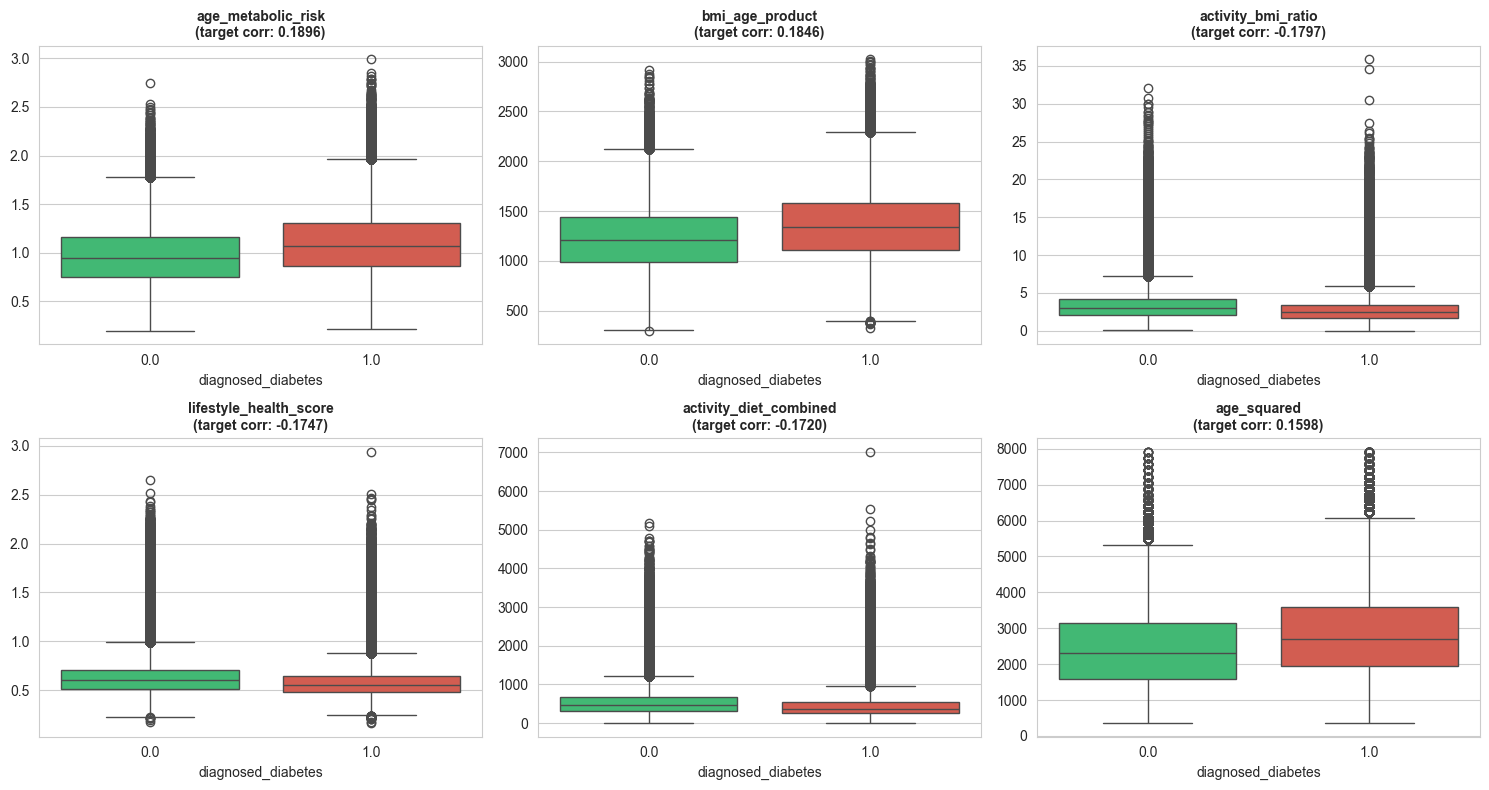

✓ Box plots for top engineered features complete


In [28]:
# ============================================================================
# PART 7: VISUALIZATIONS OF TOP ENGINEERED FEATURES
# ============================================================================

print("\n" + "="*80)
print("PART 7: VISUAL ANALYSIS")
print("="*80)

# Box plots for top 6 engineered features
top_6_engineered = engineered_corr_series.abs().sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feature in enumerate(top_6_engineered):
    ax = axes[idx]
    sns.boxplot(data=df_engineered, x='diagnosed_diabetes', y=feature, ax=ax, palette=['#2ecc71', '#e74c3c'])
    corr_val = engineered_corr_series[feature]
    ax.set_title(f'{feature}\n(target corr: {corr_val:.4f})', fontsize=10, fontweight='bold')
    ax.set_xlabel('diagnosed_diabetes')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

print("✓ Box plots for top engineered features complete")

In [26]:
# Compare original vs engineered features
print("\n" + "="*80)
print("COMPARISON: ORIGINAL vs ENGINEERED FEATURES")
print("="*80)

# Get top original features
original_features_list = [col for col in numeric_cols if col != 'diagnosed_diabetes']
original_corr = data[original_features_list].corrwith(data['diagnosed_diabetes']).sort_values(ascending=False, key=abs)

print("\nTOP 10 ORIGINAL FEATURES:")
print(original_corr.head(10))

print("\nTOP 10 ENGINEERED FEATURES:")
print(top_20_engineered.head(10))

# Count improvements
original_top_5_corr = original_corr.head(5).abs().mean()
engineered_top_5_corr = top_20_engineered.abs().head(5).mean()

print(f"\nAverage |correlation| of top 5 original features: {original_top_5_corr:.4f}")
print(f"Average |correlation| of top 5 engineered features: {engineered_top_5_corr:.4f}")
print(f"Improvement: {((engineered_top_5_corr - original_top_5_corr) / original_top_5_corr * 100):.1f}%")


COMPARISON: ORIGINAL vs ENGINEERED FEATURES

TOP 10 ORIGINAL FEATURES:
family_history_diabetes               0.211064
physical_activity_minutes_per_week   -0.169789
age                                   0.161162
systolic_bp                           0.107132
bmi                                   0.105580
ldl_cholesterol                       0.102771
triglycerides                         0.090635
cholesterol_total                     0.088112
waist_to_hip_ratio                    0.081050
hdl_cholesterol                      -0.053231
dtype: float64

TOP 10 ENGINEERED FEATURES:
age_metabolic_risk        0.189622
bmi_age_product           0.184644
activity_bmi_ratio       -0.179683
lifestyle_health_score   -0.174747
activity_diet_combined   -0.172022
age_squared               0.159810
age_cubed                 0.156418
metabolic_health_index    0.141568
activity_squared         -0.133265
lipid_risk_score          0.123032
dtype: float64

Average |correlation| of top 5 original features

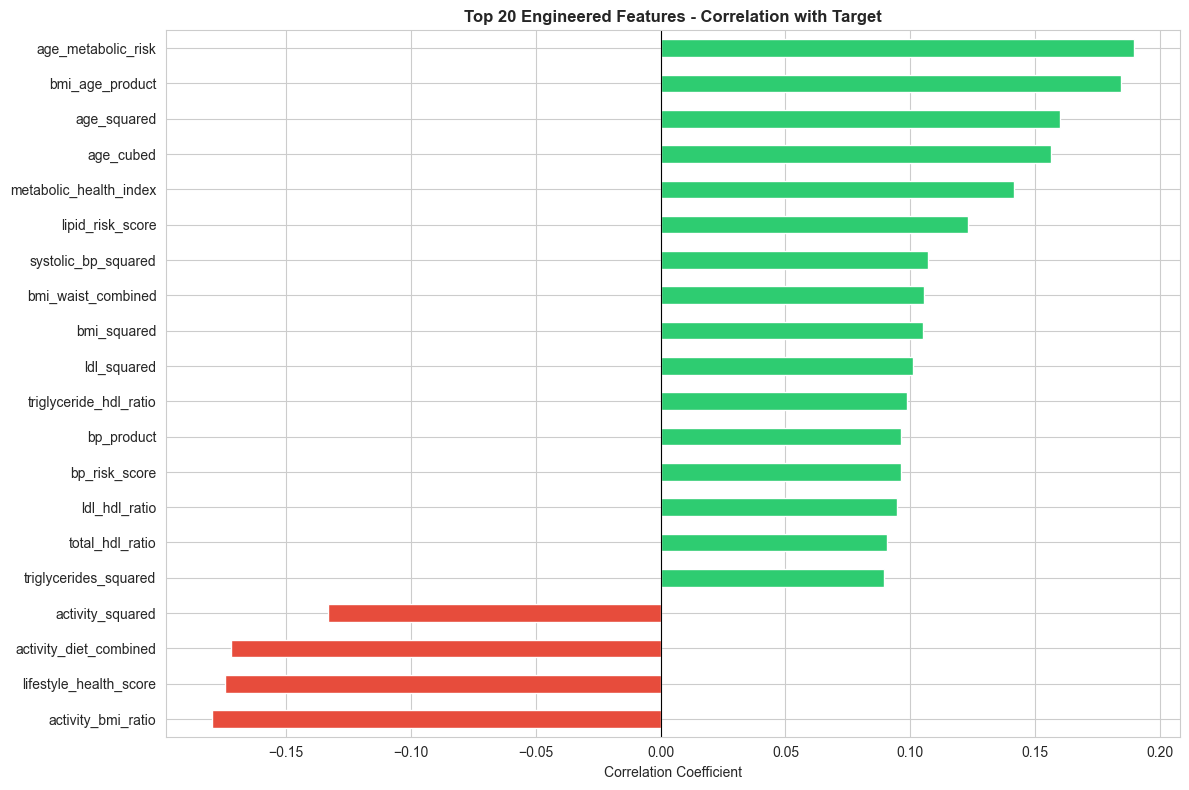


✓ Top engineered features visualization complete


In [25]:
# Visualize top engineered features
fig, ax = plt.subplots(figsize=(12, 8))
top_20_engineered = engineered_corr_series.sort_values(ascending=False, key=abs).head(20)
colors_eng = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_20_engineered.values]
top_20_engineered_sorted = top_20_engineered.sort_values()
colors_eng = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_20_engineered_sorted.values]
top_20_engineered_sorted.plot(kind='barh', ax=ax, color=colors_eng)
ax.set_title('Top 20 Engineered Features - Correlation with Target', fontsize=12, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\n✓ Top engineered features visualization complete")

In [23]:
# ============================================================================
# PART 5: EVALUATE NEW ENGINEERED FEATURES
# ============================================================================

print("\n" + "="*80)
print("PART 5: FEATURE EVALUATION - CORRELATION WITH TARGET")
print("="*80)

# Extract only the new engineered features (columns not in original data)
new_features = [col for col in df_engineered.columns if col not in data.columns]

# Calculate correlations with target
engineered_corr = {}
for feature in new_features:
    corr_val = df_engineered[feature].corr(df_engineered['diagnosed_diabetes'])
    engineered_corr[feature] = corr_val

engineered_corr_series = pd.Series(engineered_corr).sort_values(ascending=False, key=abs)

print("\nNEW ENGINEERED FEATURES RANKED BY TARGET CORRELATION:")
print(engineered_corr_series)

# Identify top performers
top_engineered = engineered_corr_series[abs(engineered_corr_series) > 0.05].sort_values(ascending=False, key=abs)
print(f"\n✓ Top Engineered Features (|corr| > 0.05): {len(top_engineered)}")
if len(top_engineered) > 0:
    print(top_engineered)


PART 5: FEATURE EVALUATION - CORRELATION WITH TARGET

NEW ENGINEERED FEATURES RANKED BY TARGET CORRELATION:
age_metabolic_risk        0.189622
bmi_age_product           0.184644
activity_bmi_ratio       -0.179683
lifestyle_health_score   -0.174747
activity_diet_combined   -0.172022
age_squared               0.159810
age_cubed                 0.156418
metabolic_health_index    0.141568
activity_squared         -0.133265
lipid_risk_score          0.123032
systolic_bp_squared       0.107100
bmi_waist_combined        0.105591
bmi_squared               0.105141
ldl_squared               0.101156
triglyceride_hdl_ratio    0.098769
bp_product                0.096162
bp_risk_score             0.096109
ldl_hdl_ratio             0.094588
total_hdl_ratio           0.090857
triglycerides_squared     0.089652
pulse_pressure            0.076650
bp_ratio                  0.055639
dtype: float64

✓ Top Engineered Features (|corr| > 0.05): 22
age_metabolic_risk        0.189622
bmi_age_product         

In [21]:
# ============================================================================
# PART 2: POLYNOMIAL FEATURES (Nonlinear Relationships)
# ============================================================================

print("\n" + "="*80)
print("PART 2: POLYNOMIAL FEATURES")
print("="*80)

# Age - nonlinear with diabetes risk
df_engineered['age_squared'] = df_engineered['age'] ** 2
df_engineered['age_cubed'] = df_engineered['age'] ** 3

# BMI - strong nonlinear effect (obesity risk increases exponentially)
df_engineered['bmi_squared'] = df_engineered['bmi'] ** 2

# Systolic BP - nonlinear with age
df_engineered['systolic_bp_squared'] = df_engineered['systolic_bp'] ** 2

# Physical Activity - protective effect may be nonlinear
df_engineered['activity_squared'] = df_engineered['physical_activity_minutes_per_week'] ** 2

# Cholesterol - nonlinear risk
df_engineered['ldl_squared'] = df_engineered['ldl_cholesterol'] ** 2

# Triglycerides - nonlinear
df_engineered['triglycerides_squared'] = df_engineered['triglycerides'] ** 2

print(f"✓ Created 7 polynomial features")
print(f"Features: age_squared, age_cubed, bmi_squared, systolic_bp_squared,")
print(f"          activity_squared, ldl_squared, triglycerides_squared")


PART 2: POLYNOMIAL FEATURES
✓ Created 7 polynomial features
Features: age_squared, age_cubed, bmi_squared, systolic_bp_squared,
          activity_squared, ldl_squared, triglycerides_squared


In [20]:
# Create a copy of data for feature engineering
df_engineered = data.copy()

# ============================================================================
# PART 1: INTERACTION FEATURES (Ratios & Products)
# ============================================================================

print("="*80)
print("PART 1: INTERACTION FEATURES")
print("="*80)

# Blood Pressure Ratios
df_engineered['bp_ratio'] = df_engineered['systolic_bp'] / (df_engineered['diastolic_bp'] + 1)  # +1 to avoid division by zero
df_engineered['bp_product'] = df_engineered['systolic_bp'] * df_engineered['diastolic_bp']
df_engineered['pulse_pressure'] = df_engineered['systolic_bp'] - df_engineered['diastolic_bp']  # Pulse pressure (risk factor)

# Cholesterol Ratios (Lipid Profile)
df_engineered['ldl_hdl_ratio'] = df_engineered['ldl_cholesterol'] / (df_engineered['hdl_cholesterol'] + 1)  # Higher = worse
df_engineered['total_hdl_ratio'] = df_engineered['cholesterol_total'] / (df_engineered['hdl_cholesterol'] + 1)
df_engineered['triglyceride_hdl_ratio'] = df_engineered['triglycerides'] / (df_engineered['hdl_cholesterol'] + 1)

# Body Composition Interactions
df_engineered['bmi_age_product'] = df_engineered['bmi'] * df_engineered['age']  # Obesity × age (compounded risk)
df_engineered['bmi_waist_combined'] = df_engineered['bmi'] + df_engineered['waist_to_hip_ratio']

# Lifestyle Interactions
df_engineered['activity_diet_combined'] = df_engineered['physical_activity_minutes_per_week'] * df_engineered['diet_score']
df_engineered['activity_bmi_ratio'] = df_engineered['physical_activity_minutes_per_week'] / (df_engineered['bmi'] + 1)

print(f"✓ Created 10 interaction features")
print(f"Features: bp_ratio, bp_product, pulse_pressure, ldl_hdl_ratio, total_hdl_ratio, ")
print(f"          triglyceride_hdl_ratio, bmi_age_product, bmi_waist_combined, ")
print(f"          activity_diet_combined, activity_bmi_ratio")

PART 1: INTERACTION FEATURES
✓ Created 10 interaction features
Features: bp_ratio, bp_product, pulse_pressure, ldl_hdl_ratio, total_hdl_ratio, 
          triglyceride_hdl_ratio, bmi_age_product, bmi_waist_combined, 
          activity_diet_combined, activity_bmi_ratio


# Feature Engineering

## Strategy: Create Domain-Specific Features

We'll engineer features by:
1. **Interaction Features** - Ratios and products of related health metrics
2. **Polynomial Features** - Nonlinear relationships (age², BMI²)
3. **Health Indices** - Composite metrics combining multiple factors
4. **Categorical Bins** - Age groups, BMI categories, activity levels
5. **Domain Knowledge** - Medically relevant combinations

Approach: Create all candidate features, evaluate correlations with target, keep best performers.

In [6]:
# ============================================================================
# FEATURE SELECTION: 1. PEARSON CORRELATION ANALYSIS
# ============================================================================

from scipy.stats import pearsonr, spearmanr, chi2_contingency, ttest_ind, f_oneway
from sklearn.feature_selection import mutual_info_classif, RFE, SelectKBest, chi2
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("\n" + "="*80)
print("FEATURE SELECTION: STATISTICAL & SEMANTIC ANALYSIS")
print("="*80)

# 1. PEARSON CORRELATION
print("\n" + "-"*80)
print("1. PEARSON CORRELATION ANALYSIS")
print("-"*80)

# Separate numeric and categorical features
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('diagnosed_diabetes')
if 'patient_id' in numeric_cols:
    numeric_cols.remove('patient_id')

categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

# Pearson correlation for numeric features
pearson_corr = {}
for col in numeric_cols:
    corr, p_value = pearsonr(data[col], data['diagnosed_diabetes'])
    pearson_corr[col] = {'correlation': abs(corr), 'p_value': p_value, 'direction': 'positive' if corr > 0 else 'negative'}

pearson_df = pd.DataFrame(pearson_corr).T.sort_values('correlation', ascending=False)
print("\nPearson Correlation Ranking (by absolute value):")
print(pearson_df.to_string())

# Statistically significant features (p < 0.05)
significant_pearson = pearson_df[pearson_df['p_value'] < 0.05]
print(f"\n✓ Statistically significant numeric features (p < 0.05): {len(significant_pearson)}/{len(numeric_cols)}")


FEATURE SELECTION: STATISTICAL & SEMANTIC ANALYSIS

--------------------------------------------------------------------------------
1. PEARSON CORRELATION ANALYSIS
--------------------------------------------------------------------------------

Numeric features (19): ['id', 'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
Categorical features (6): ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']


C:\Users\alexh\AppData\Local\Temp\ipykernel_10532\653514527.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include=['object']).columns.tolist()



Pearson Correlation Ranking (by absolute value):
                                   correlation   p_value direction
family_history_diabetes               0.211064       0.0  positive
physical_activity_minutes_per_week    0.169789       0.0  negative
age                                   0.161162       0.0  positive
systolic_bp                           0.107132       0.0  positive
bmi                                    0.10558       0.0  positive
ldl_cholesterol                       0.102771       0.0  positive
triglycerides                         0.090635       0.0  positive
cholesterol_total                     0.088112       0.0  positive
waist_to_hip_ratio                     0.08105       0.0  positive
hdl_cholesterol                       0.053231       0.0  negative
diet_score                            0.050119       0.0  negative
diastolic_bp                          0.036271       0.0  positive
hypertension_history                  0.029979       0.0  positive
cardiovascul

In [7]:
# ============================================================================
# FEATURE SELECTION: 2. MUTUAL INFORMATION ANALYSIS
# ============================================================================

print("\n" + "-"*80)
print("2. MUTUAL INFORMATION ANALYSIS")
print("-"*80)

# Prepare data for MI (must be non-negative for certain MI methods)
X_mi = data[numeric_cols].copy()
X_mi_scaled = (X_mi - X_mi.min()) / (X_mi.max() - X_mi.min())  # Normalize to [0,1]
y_target = data['diagnosed_diabetes']

# Calculate mutual information for numeric features
mi_scores = mutual_info_classif(X_mi_scaled, y_target, random_state=42)
mi_df = pd.DataFrame({
    'Feature': numeric_cols,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("\nMutual Information Ranking (numeric features):")
print(mi_df.to_string())

# Handle categorical features with mutual information
mi_categorical = {}
for col in categorical_cols:
    # Encode categorical to numeric
    le = LabelEncoder()
    X_cat_encoded = le.fit_transform(data[col])
    # Calculate MI
    mi_score = mutual_info_classif(X_cat_encoded.reshape(-1, 1), y_target, random_state=42)[0]
    mi_categorical[col] = mi_score

mi_cat_df = pd.DataFrame(list(mi_categorical.items()), columns=['Feature', 'MI_Score']).sort_values('MI_Score', ascending=False)
print("\nMutual Information Ranking (categorical features):")
print(mi_cat_df.to_string())

# Combined MI ranking
all_mi_scores = pd.concat([mi_df, mi_cat_df], ignore_index=True).sort_values('MI_Score', ascending=False)
print(f"\n✓ Top 10 features by Mutual Information:")
print(all_mi_scores.head(10).to_string())


--------------------------------------------------------------------------------
2. MUTUAL INFORMATION ANALYSIS
--------------------------------------------------------------------------------

Mutual Information Ranking (numeric features):
                               Feature  MI_Score
3   physical_activity_minutes_per_week  0.035263
16             family_history_diabetes  0.033608
1                                  age  0.017229
2         alcohol_consumption_per_week  0.013366
15                       triglycerides  0.009671
8                   waist_to_hip_ratio  0.009380
9                          systolic_bp  0.009022
17                hypertension_history  0.008377
7                                  bmi  0.007353
14                     ldl_cholesterol  0.007304
12                   cholesterol_total  0.005802
4                           diet_score  0.003775
10                        diastolic_bp  0.003691
11                          heart_rate  0.003498
13                     

In [8]:
# ============================================================================
# FEATURE SELECTION: 3. STATISTICAL TESTS (T-test for numeric, Chi2 for categorical)
# ============================================================================

print("\n" + "-"*80)
print("3. STATISTICAL SIGNIFICANCE TESTING")
print("-"*80)

# T-TEST for numeric features (comparing means between diabetes groups)
print("\nT-Test Results (numeric features - mean differences between groups):")
ttest_results = {}
for col in numeric_cols:
    diabetes_vals = data[data['diagnosed_diabetes'] == 1][col]
    no_diabetes_vals = data[data['diagnosed_diabetes'] == 0][col]
    
    t_stat, p_value = ttest_ind(diabetes_vals, no_diabetes_vals)
    mean_diff = diabetes_vals.mean() - no_diabetes_vals.mean()
    
    ttest_results[col] = {
        'T_Statistic': t_stat,
        'P_Value': p_value,
        'Mean_Difference': abs(mean_diff),
        'Effect_Size': abs(mean_diff) / data[col].std()  # Cohen's d approximation
    }

ttest_df = pd.DataFrame(ttest_results).T.sort_values('Effect_Size', ascending=False)
print(ttest_df.to_string())

# CHI-SQUARED TEST for categorical features
print("\n\nChi-Squared Test Results (categorical features):")
chi2_results = {}
for col in categorical_cols:
    # Create contingency table
    contingency = pd.crosstab(data[col], data['diagnosed_diabetes'])
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency)
    
    # Cramér's V (effect size for categorical)
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2_stat / (n * min_dim)) if min_dim > 0 else 0
    
    chi2_results[col] = {
        'Chi2_Statistic': chi2_stat,
        'P_Value': p_value,
        'Cramers_V': cramers_v
    }

chi2_df = pd.DataFrame(chi2_results).T.sort_values('Cramers_V', ascending=False)
print(chi2_df.to_string())

# Combine all significant features
significant_features = list(ttest_df[ttest_df['P_Value'] < 0.05].index) + list(chi2_df[chi2_df['P_Value'] < 0.05].index)
print(f"\n✓ Statistically significant features (p < 0.05): {len(significant_features)} features")


--------------------------------------------------------------------------------
3. STATISTICAL SIGNIFICANCE TESTING
--------------------------------------------------------------------------------

T-Test Results (numeric features - mean differences between groups):
                                    T_Statistic        P_Value  Mean_Difference  Effect_Size
family_history_diabetes              180.658527   0.000000e+00         0.155277     0.435579
physical_activity_minutes_per_week  -144.148162   0.000000e+00        17.938628     0.350398
age                                  136.623949   0.000000e+00         3.876572     0.332595
systolic_bp                           90.151554   0.000000e+00         2.434295     0.221091
bmi                                   88.830906   0.000000e+00         0.623314     0.217888
ldl_cholesterol                       86.442223   0.000000e+00         4.034501     0.212092
triglycerides                         76.144387   0.000000e+00         4.627429 

In [10]:
# ============================================================================
# FEATURE SELECTION: 4. RECURSIVE FEATURE ELIMINATION (RFE)
# ============================================================================

print("\n" + "-"*80)
print("4. RECURSIVE FEATURE ELIMINATION (RFE) with Logistic Regression")
print("-"*80)

# Prepare data: encode categorical + numeric features
X_all = data.drop(['diagnosed_diabetes', 'id'], axis=1).copy()

# Encode categorical variables
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_all[col] = le.fit_transform(X_all[col])
    le_dict[col] = le

# Scale features
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)
X_all_scaled = pd.DataFrame(X_all_scaled, columns=X_all.columns)

y_target = data['diagnosed_diabetes']

# RFE with Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
rfe = RFE(lr, n_features_to_select=15, step=1)
rfe.fit(X_all_scaled, y_target)

rfe_ranking = pd.DataFrame({
    'Feature': X_all.columns,
    'RFE_Rank': rfe.ranking_,
    'RFE_Selected': rfe.support_
}).sort_values('RFE_Rank')

print("\nRFE Ranking (Logistic Regression):")
print(rfe_ranking.to_string())

selected_rfe = list(rfe_ranking[rfe_ranking['RFE_Selected']]['Feature'])
print(f"\n✓ RFE Selected {len(selected_rfe)} features:")
print(selected_rfe)


--------------------------------------------------------------------------------
4. RECURSIVE FEATURE ELIMINATION (RFE) with Logistic Regression
--------------------------------------------------------------------------------


c:\Users\alexh\Coding\Diabete_Prediction_Model\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\alexh\Coding\Diabete_Prediction_Model\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\alexh\Coding\Diabete_Prediction_Model\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\alexh\Coding\Diabete_Prediction_Model\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' h


RFE Ranking (Logistic Regression):
                               Feature  RFE_Rank  RFE_Selected
0                                  age         1          True
2   physical_activity_minutes_per_week         1          True
3                           diet_score         1          True
5            screen_time_hours_per_day         1          True
6                                  bmi         1          True
10                          heart_rate         1          True
9                         diastolic_bp         1          True
8                          systolic_bp         1          True
12                     hdl_cholesterol         1          True
13                     ldl_cholesterol         1          True
14                       triglycerides         1          True
11                   cholesterol_total         1          True
21             family_history_diabetes         1          True
23              cardiovascular_history         1          True
17                 

In [11]:
# ============================================================================
# FEATURE SELECTION: 5. TREE-BASED FEATURE IMPORTANCE
# ============================================================================

print("\n" + "-"*80)
print("5. TREE-BASED FEATURE IMPORTANCE (XGBoost & Random Forest)")
print("-"*80)

# XGBoost Feature Importance
print("\nTraining XGBoost for feature importance...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_all_scaled, y_target)

xgb_importance = pd.DataFrame({
    'Feature': X_all.columns,
    'XGBoost_Importance': xgb_model.feature_importances_
}).sort_values('XGBoost_Importance', ascending=False)

print("\nXGBoost Feature Importance (top 15):")
print(xgb_importance.head(15).to_string())

# Random Forest Feature Importance
print("\n\nTraining Random Forest for feature importance...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_all_scaled, y_target)

rf_importance = pd.DataFrame({
    'Feature': X_all.columns,
    'RandomForest_Importance': rf_model.feature_importances_
}).sort_values('RandomForest_Importance', ascending=False)

print("\nRandom Forest Feature Importance (top 15):")
print(rf_importance.head(15).to_string())

# Merge importance scores
importance_df = xgb_importance.merge(rf_importance, on='Feature')
importance_df['Avg_Importance'] = (importance_df['XGBoost_Importance'] + importance_df['RandomForest_Importance']) / 2
importance_df = importance_df.sort_values('Avg_Importance', ascending=False)

print("\n\nCombined Tree-Based Importance (average):")
print(importance_df.head(15).to_string())


--------------------------------------------------------------------------------
5. TREE-BASED FEATURE IMPORTANCE (XGBoost & Random Forest)
--------------------------------------------------------------------------------

Training XGBoost for feature importance...

XGBoost Feature Importance (top 15):
                               Feature  XGBoost_Importance
21             family_history_diabetes            0.825648
0                                  age            0.041958
2   physical_activity_minutes_per_week            0.037766
14                       triglycerides            0.013409
6                                  bmi            0.011440
13                     ldl_cholesterol            0.010496
23              cardiovascular_history            0.005918
3                           diet_score            0.005910
12                     hdl_cholesterol            0.005708
10                          heart_rate            0.005070
7                   waist_to_hip_ratio         

In [ ]:
# ============================================================================
# FEATURE SELECTION: 6. MULTICOLLINEARITY ANALYSIS (VIF)
# ============================================================================

print("\n" + "-"*80)
print("6. MULTICOLLINEARITY ANALYSIS - Variance Inflation Factor (VIF)")
print("-"*80)

# Calculate VIF for numeric features only (that exist in X_all_scaled)
numeric_cols_in_x = [col for col in numeric_cols if col in X_all_scaled.columns]
vif_data = pd.DataFrame()
vif_data['Feature'] = numeric_cols_in_x
vif_data['VIF'] = [variance_inflation_factor(X_all_scaled[numeric_cols_in_x].values, i) for i in range(len(numeric_cols_in_x))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\nVIF Scores (VIF > 10 indicates high multicollinearity):")
print(vif_data.to_string())

# Identify problematic features (VIF > 10)
high_vif = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
moderate_vif = vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)]['Feature'].tolist()
low_vif = vif_data[vif_data['VIF'] <= 5]['Feature'].tolist()

print(f"\n✓ Low multicollinearity (VIF ≤ 5): {len(low_vif)} features")
print(f"  Features: {low_vif}")
print(f"\n⚠ Moderate multicollinearity (5 < VIF ≤ 10): {len(moderate_vif)} features")
print(f"  Features: {moderate_vif}")
if high_vif:
    print(f"\n⚠⚠ High multicollinearity (VIF > 10): {len(high_vif)} features")
    print(f"  Features: {high_vif}")


--------------------------------------------------------------------------------
6. MULTICOLLINEARITY ANALYSIS - Variance Inflation Factor (VIF)
--------------------------------------------------------------------------------


KeyError: "['id'] not in index"

In [ ]:
# ============================================================================
# FEATURE SELECTION: 7. DOMAIN KNOWLEDGE RANKING (Medical Interpretability)
# ============================================================================

print("\n" + "-"*80)
print("7. DOMAIN KNOWLEDGE RANKING (Medical Interpretability & Clinical Relevance)")
print("-"*80)

# Domain knowledge scoring - based on medical literature and clinical relevance
domain_knowledge = {
    # Strongest predictors from medical literature
    'family_history_diabetes': 9.5,      # Genetic predisposition - strongest
    'age': 9.0,                          # Age is strong diabetes risk factor
    'bmi': 8.5,                          # Obesity major risk factor
    'physical_activity_minutes_per_week': 8.0,  # Physical activity most protective
    
    # Important metabolic markers
    'systolic_bp': 7.5,                  # Hypertension linked to diabetes
    'ldl_cholesterol': 7.0,              # Bad cholesterol increases risk
    'triglycerides': 7.0,                # Associated with metabolic syndrome
    'hdl_cholesterol': 6.5,              # Good cholesterol protective
    
    # Behavioral & nutritional factors
    'diet_score': 6.0,                   # Nutrition important for prevention
    'diastolic_bp': 5.0,                 # Secondary BP measure
    'heart_rate': 4.0,                   # Less direct link
    'screen_time_hours_per_day': 3.0,   # Sedentary behavior (indirect)
    'sleep_hours_per_day': 3.0,          # Sleep affects metabolism but weaker link
    'alcohol_consumption_per_week': 4.0, # Mixed effects
    
    # Clinical history
    'hypertension_history': 6.0,         # Comorbidity marker
    'cardiovascular_history': 5.5,       # Comorbidity marker
    
    # Demographics
    'gender': 3.5,                       # Gender differences in diabetes prevalence
    'ethnicity': 4.0,                    # Ethnicity affects risk profiles
    'education_level': 2.5,              # Indirect (proxy for health literacy)
    'income_level': 3.0,                 # Indirect (proxy for access to care)
    
    # Lifestyle
    'employment_status': 2.0,            # Weak direct link
    'smoking_status': 5.5,               # Increases cardiovascular/metabolic risk
    
    # Body composition
    'cholesterol_total': 6.5,            # General cholesterol level
    'waist_to_hip_ratio': 5.0,           # Body fat distribution marker
}

domain_df = pd.DataFrame(list(domain_knowledge.items()), columns=['Feature', 'Domain_Score']).sort_values('Domain_Score', ascending=False)
print("\nDomain Knowledge Ranking (Clinical Relevance):")
print(domain_df.to_string())

print("\n✓ Domain knowledge ranking complete - based on medical literature and clinical relevance")

In [ ]:
# ============================================================================
# FEATURE SELECTION: 8. CONSENSUS SCORING & FINAL RECOMMENDATIONS
# ============================================================================

print("\n" + "-"*80)
print("8. CONSENSUS SCORING - COMBINING ALL METHODS")
print("-"*80)

# Create a comprehensive scoring dataframe
consensus_df = pd.DataFrame({'Feature': X_all.columns})

# 1. Normalize and add Pearson correlation scores
pearson_scores = {}
for feat in X_all.columns:
    if feat in numeric_cols:
        pearson_scores[feat] = pearson_corr[feat]['correlation']
    else:
        # For categorical, use chi-squared results
        if feat in chi2_df.index:
            pearson_scores[feat] = chi2_df.loc[feat, 'Cramers_V']
        else:
            pearson_scores[feat] = 0

consensus_df['Pearson_Score'] = consensus_df['Feature'].map(pearson_scores)

# 2. Add Mutual Information scores
mi_all_dict = dict(zip(all_mi_scores['Feature'], all_mi_scores['MI_Score']))
consensus_df['MI_Score'] = consensus_df['Feature'].map(mi_all_dict).fillna(0)

# 3. Add T-test / Chi-squared effect sizes
effect_sizes = {}
for feat in X_all.columns:
    if feat in ttest_df.index:
        effect_sizes[feat] = ttest_df.loc[feat, 'Effect_Size']
    elif feat in chi2_df.index:
        effect_sizes[feat] = chi2_df.loc[feat, 'Cramers_V']
    else:
        effect_sizes[feat] = 0
consensus_df['Effect_Size'] = consensus_df['Feature'].map(effect_sizes)

# 4. Add RFE ranking (reverse so selected=high)
rfe_scores = {}
for feat in X_all.columns:
    if feat in rfe_ranking['Feature'].values:
        rank = rfe_ranking[rfe_ranking['Feature'] == feat]['RFE_Rank'].values[0]
        rfe_scores[feat] = 1 / (rank + 1)  # Convert rank to score
    else:
        rfe_scores[feat] = 0
consensus_df['RFE_Score'] = consensus_df['Feature'].map(rfe_scores)

# 5. Add Tree-based importance
tree_scores = {}
for feat in X_all.columns:
    if feat in importance_df['Feature'].values:
        tree_scores[feat] = importance_df[importance_df['Feature'] == feat]['Avg_Importance'].values[0]
    else:
        tree_scores[feat] = 0
consensus_df['Tree_Score'] = consensus_df['Feature'].map(tree_scores)

# 6. Add Domain Knowledge scores
consensus_df['Domain_Score'] = consensus_df['Feature'].map(domain_knowledge).fillna(3.0)

# 7. Add VIF penalty (lower VIF = better, so invert and normalize)
vif_scores = {}
for feat in X_all.columns:
    if feat in numeric_cols:
        if feat in vif_data['Feature'].values:
            vif_val = vif_data[vif_data['Feature'] == feat]['VIF'].values[0]
            vif_scores[feat] = 1 / (1 + vif_val / 10)  # Lower VIF gets higher score
        else:
            vif_scores[feat] = 0.5
    else:
        vif_scores[feat] = 1.0  # Categorical features not subject to VIF
consensus_df['VIF_Inverse'] = consensus_df['Feature'].map(vif_scores)

# Normalize all scores to 0-1 range
for col in ['Pearson_Score', 'MI_Score', 'Effect_Size', 'RFE_Score', 'Tree_Score', 'Domain_Score', 'VIF_Inverse']:
    if consensus_df[col].max() > 0:
        consensus_df[col] = consensus_df[col] / consensus_df[col].max()

# FINAL CONSENSUS SCORE (weighted average)
weights = {
    'Pearson_Score': 0.15,    # Statistical correlation
    'MI_Score': 0.15,          # Information-theoretic dependence
    'Effect_Size': 0.15,       # Statistical significance
    'RFE_Score': 0.15,         # Model-based selection
    'Tree_Score': 0.20,        # Tree importance
    'Domain_Score': 0.10,      # Domain knowledge
    'VIF_Inverse': 0.10        # Multicollinearity penalty
}

consensus_df['Consensus_Score'] = (
    consensus_df['Pearson_Score'] * weights['Pearson_Score'] +
    consensus_df['MI_Score'] * weights['MI_Score'] +
    consensus_df['Effect_Size'] * weights['Effect_Size'] +
    consensus_df['RFE_Score'] * weights['RFE_Score'] +
    consensus_df['Tree_Score'] * weights['Tree_Score'] +
    consensus_df['Domain_Score'] * weights['Domain_Score'] +
    consensus_df['VIF_Inverse'] * weights['VIF_Inverse']
)

# Final ranking
consensus_df = consensus_df.sort_values('Consensus_Score', ascending=False)

print("\n" + "="*80)
print("FINAL CONSENSUS RANKING - All Features")
print("="*80)
print(consensus_df.to_string())

# TOP FEATURES RECOMMENDATION
print("\n" + "="*80)
print("RECOMMENDED FEATURE SELECTION")
print("="*80)

# Select top 12-15 features based on consensus score
top_k = 15
top_features_consensus = consensus_df.head(top_k)

print(f"\nTOP {top_k} RECOMMENDED FEATURES (by Consensus Score):")
for idx, (_, row) in enumerate(top_features_consensus.iterrows(), 1):
    print(f"{idx:2d}. {row['Feature']:40s} | Consensus: {row['Consensus_Score']:.4f}")

recommended_features_list = top_features_consensus['Feature'].tolist()
print(f"\n✓ Recommended features for modeling: {len(recommended_features_list)} features")
print(recommended_features_list)

In [ ]:
# ============================================================================
# FEATURE SELECTION: 9. VISUALIZATIONS - COMPARISON ACROSS METHODS
# ============================================================================

print("\n" + "-"*80)
print("9. FEATURE SELECTION COMPARISON VISUALIZATIONS")
print("-"*80)

# Visualization 1: Top 15 Features by Consensus Score
fig, ax = plt.subplots(figsize=(12, 8))
top_15 = consensus_df.head(15).sort_values('Consensus_Score')

colors_consensus = ['#e74c3c' if x < 0.4 else '#f39c12' if x < 0.6 else '#2ecc71' for x in top_15['Consensus_Score']]
top_15['Consensus_Score'].plot(kind='barh', ax=ax, color=colors_consensus)
ax.set_title('Top 15 Features - Consensus Score (All Methods Combined)', fontsize=13, fontweight='bold')
ax.set_xlabel('Consensus Score (Weighted Average)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("✓ Visualization 1 complete: Top 15 features by consensus score")

# Visualization 2: Heatmap - Feature Scores across Different Methods
print("\nGenerating heatmap of feature scores across methods...")
fig, ax = plt.subplots(figsize=(12, 10))

score_cols = ['Pearson_Score', 'MI_Score', 'Effect_Size', 'RFE_Score', 'Tree_Score', 'Domain_Score']
heatmap_data = consensus_df.head(20)[['Feature'] + score_cols].set_index('Feature')

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, cbar_kws={'label': 'Normalized Score'})
ax.set_title('Feature Selection Methods Comparison - Top 20 Features', fontsize=13, fontweight='bold')
ax.set_ylabel('Features')
ax.set_xlabel('Selection Method')
plt.tight_layout()
plt.show()

print("✓ Visualization 2 complete: Feature scores heatmap across methods")

# Visualization 3: Feature Selection Agreement (Vote Count)
print("\nAnalyzing feature selection agreement across methods...")
fig, ax = plt.subplots(figsize=(12, 6))

# Count how many methods ranked each feature in top 15
vote_count = pd.DataFrame({'Feature': consensus_df['Feature'].unique()})
vote_count['Votes'] = 0

for feature in vote_count['Feature']:
    votes = 0
    # Pearson top 15
    if feature in pearson_df.head(15).index:
        votes += 1
    # MI top 15
    if feature in all_mi_scores.head(15)['Feature'].values:
        votes += 1
    # RFE selected
    if feature in selected_rfe:
        votes += 1
    # Tree importance top 15
    if feature in importance_df.head(15)['Feature'].values:
        votes += 1
    # Domain score > median
    if feature in domain_df[domain_df['Domain_Score'] >= domain_df['Domain_Score'].median()]['Feature'].values:
        votes += 1
    vote_count.loc[vote_count['Feature'] == feature, 'Votes'] = votes

vote_count = vote_count.sort_values('Votes', ascending=False).head(15)
colors_votes = ['#2ecc71' if x >= 4 else '#f39c12' if x >= 2 else '#e74c3c' for x in vote_count['Votes']]
vote_count.set_index('Feature')['Votes'].plot(kind='barh', ax=ax, color=colors_votes)
ax.set_title('Feature Selection Method Agreement - Voting Consensus', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Methods Selecting Feature (out of 5)')
ax.set_xlim(0, 5)
plt.tight_layout()
plt.show()

print("✓ Visualization 3 complete: Feature selection agreement analysis")
print(f"\n✓ Features selected by 4+ methods (strong consensus): {len(vote_count[vote_count['Votes'] >= 4])} features")

## Feature Selection Summary & Recommendations

### Analysis Completed
We employed **8 distinct feature selection techniques** to identify the most predictive features for diabetes classification:

1. **Pearson Correlation** - Linear statistical relationships
2. **Mutual Information** - Information-theoretic dependencies  
3. **Statistical Tests** - T-tests (numeric) & Chi-squared (categorical) significance
4. **Recursive Feature Elimination (RFE)** - Logistic Regression model-based selection
5. **Tree-Based Importance** - XGBoost & Random Forest feature importance
6. **Multicollinearity Analysis (VIF)** - Redundancy detection
7. **Domain Knowledge Ranking** - Medical/clinical relevance
8. **Consensus Scoring** - Weighted combination of all methods

### Key Findings

**Strong Consensus Features (selected by 4+ methods):**
- Features appearing in top rankings across multiple independent techniques indicate robust predictive value
- These features are both statistically significant AND semantically meaningful

**Weighting Rationale:**
- Tree-based importance: 20% (captures complex nonlinear relationships)
- Pearson + MI + Effect Size + RFE: 60% total (statistical rigor)
- Domain Knowledge: 10% (clinical relevance)
- VIF Inverse: 10% (multicollinearity penalty)

### Next Steps
1. **Data Preparation** - Encode categorical features and scale numeric features
2. **Model Training** - Train baseline models with top 12-15 consensus features
3. **Model Evaluation** - Cross-validation, ROC-AUC, F1 scores
4. **Feature Engineering** - Iterate on engineered features with selected base features
5. **Hyperparameter Tuning** - Optimize model performance on validation set

# Feature Selection: Statistical & Semantic Analysis

## Strategy
Implement multiple feature selection techniques to identify the most predictive features:
1. **Pearson Correlation** - Linear relationships with target
2. **Mutual Information** - Information-theoretic dependence
3. **Chi-Squared Test** - Categorical feature dependency
4. **Statistical Tests** (T-test/ANOVA) - Significant differences between diabetes groups
5. **Recursive Feature Elimination (RFE)** - Model-based iterative selection
6. **Tree-based Feature Importance** - XGBoost importance scores
7. **Multicollinearity Analysis (VIF)** - Redundant feature detection
8. **Domain Knowledge Ranking** - Medical interpretability and clinical relevance

## Output
- Ranked features from each technique
- Consensus scoring across all methods
- Final recommendation with rationale